# SOTJ 2025: All Figures
The following code includes all figures that have been used in the State of Tax Justice 2025

### 0. Packages, paths, and general functions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl
import requests

from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch

import os
from pathlib import Path
from typing import Tuple

import re
from collections import defaultdict

In [2]:
# Define figure output path once
FIG_PATH = r"C:/Users/aliso/Dropbox/Apps/Overleaf/SOTJ 2025/Figures/en"
TAB_PATH = r"C:/Users/aliso/Dropbox/Apps/Overleaf/SOTJ 2025/Tables/en"
FIG_PATH2 = r"C:/Users/aliso/Dropbox/Apps/Overleaf/SOTJ_2025_presentation/1_figures/en"
TAB_PATH2 = r"C:/Users/aliso/Dropbox/Apps/Overleaf/SOTJ_2025_presentation/2_tables/en"
SOTJ25_FOLDER = r"C:/Users/aliso/Tax Justice Network Ltd/TJN - Shared Documents/Research team/Projects long-term/SOTJ/SOTJ_2025"
TAB_PATH = Path(TAB_PATH)               
FIG_PATH = Path(FIG_PATH)      
TAB_PATH2 = Path(TAB_PATH2)               
FIG_PATH2 = Path(FIG_PATH2)           
SOTJ25_FOLDER = Path(SOTJ25_FOLDER)     
# Make sure the folder exists
os.makedirs(FIG_PATH, exist_ok=True)
os.makedirs(TAB_PATH, exist_ok=True)
os.makedirs(FIG_PATH2, exist_ok=True)
os.makedirs(TAB_PATH2, exist_ok=True)
os.makedirs(SOTJ25_FOLDER, exist_ok=True)

In [3]:
# --- Branding colours ---
COLORS = {
    "gold": "#FFD371",
    "earthgreen": "#50805E",
    "white": "#FFFFFF",
    "red": "#AD756C",
    "teal": "#45636C",
    "brown": "#AE8D6C",
    "blue": "#586AAD",
    "purple": "#83708d",
    "light_purple":"#c1b7c7",
    "dark_purple": "#564a5c",
    "grey": "#979aaa",
    "beige": "#ebdfdf"
}

# Set global font to Verdana
mpl.rcParams["font.family"] = "Verdana"
mpl.rcParams["axes.facecolor"] = COLORS["white"]
mpl.rcParams["figure.facecolor"] = COLORS["white"]

In [4]:
def add_tcja_marker(
    ax,
    years,
    *,
    x_positions=None,
    tcja_year=2017.5,
    label="Tax Cuts and Jobs Act",
    color=None,
    linestyle=":",
    linewidth=2.0,
    x_offset=0.10,
    y_pos="top",
    pad_frac=0.05,
    show_label=True,
    fontsize=9,
    ha="left",
    line_bottom_frac=0.0,   # NEW: start of the vertical line in axes coords (0 = bottom)
    line_top_frac=1.0,      # NEW: end of the vertical line in axes coords (1 = top)
    **text_kwargs
):
    """
    Add a vertical TCJA marker at `tcja_year` and an optional label.

    The vertical line is drawn in axes coordinates from `line_bottom_frac` to
    `line_top_frac` (so it doesn't have to span the full height).
    """
    import numpy as np

    color = color or COLORS.get("purple", "#83708d")

    yrs = np.asarray(years, dtype=float)
    if yrs.size < 2:
        return None, None

    if x_positions is None:
        x_positions = np.arange(len(yrs), dtype=float)
    else:
        x_positions = np.asarray(x_positions, dtype=float)
        if x_positions.shape != yrs.shape:
            raise ValueError("`x_positions` must have same shape as `years`.")

    if not (tcja_year >= np.nanmin(yrs) and tcja_year <= np.nanmax(yrs)):
        return None, None

    x_tcja = np.interp(tcja_year, yrs, x_positions)

    # Draw a vertical segment in axes coords so we can cap its height
    vline = ax.vlines(
        x_tcja,
        ymin=line_bottom_frac,
        ymax=line_top_frac,
        transform=ax.get_xaxis_transform(),   # x in data coords, y in axes fraction
        colors=color,
        linestyles=linestyle,
        linewidths=linewidth,
        zorder=3
    )

    text = None
    if show_label:
        y_min, y_max = ax.get_ylim()
        if isinstance(y_pos, (int, float)):
            y_text = float(y_pos)
            va = text_kwargs.pop("va", "center")
        else:
            rng = (y_max - y_min) if np.isfinite(y_max - y_min) and (y_max - y_min) != 0 else 1.0
            if y_pos == "bottom":
                y_text = y_min + pad_frac * rng
                va = text_kwargs.pop("va", "bottom")
            else:
                y_text = y_max - pad_frac * rng
                va = text_kwargs.pop("va", "top")

        text = ax.text(
            x_tcja + x_offset, y_text, label,
            color=color, fontsize=fontsize, ha=ha, va=va,
            clip_on=False, **text_kwargs
        )

    return vline, text


In [5]:
# CPI index (2021 = 100), as provided by the IMF for the US (all items) here: https://data.imf.org/en/Data-Explorer?datasetUrn=IMF.STA:CPI(5.0.0)
cpi_index = pd.Series({
    2015: 108.695722,
    2016: 110.0670089,
    2017: 112.4115573,
    2018: 115.1573032,
    2019: 117.2441955,
    2020: 118.6905016,
    2021: 124.2664138,
    2022: 134.2112062,
    2023: 139.7357936,
    2024: 143.857336
}, name="cpi").rename_axis("year").reset_index()

# --- Exchange rates from WDI (PA.NUS.FCRF: official exchange rate, LCU per USD) ---
exchange_rates = pd.read_csv(
    "../data/2025/raw/API_PA.NUS.FCRF_DS2_en_csv_v2_114.csv",
    skiprows=4
)

fx2021 = (
    exchange_rates.loc[:, ["Country Code", "Country Name", "2021"]]
    .rename(columns={
        "Country Code": "iso_partner",        # key you can reuse elsewhere
        "Country Name": "wb_country_name",
        "2021": "exchange_rate_2021"          # LCU per 1 USD (here: EUR per USD for Germany)
    })
)

# ensure numeric (some WDI CSVs load years as strings)
fx2021["exchange_rate_2021"] = pd.to_numeric(
    fx2021["exchange_rate_2021"],
    errors="coerce"
)

				
def deflate_to_base_dataset(df: pd.DataFrame,
                            cpi_df: pd.DataFrame,
                            year_col: str = "year",
                            base_year: int = 2021,
                            extra_exclude: list[str] | None = None) -> pd.DataFrame:
    """
    Convert nominal values in year t to base_year USD using CPI:
        real_base = nominal_t * (CPI_base / CPI_t)

    Keeps `year_col` in the output and never deflates it.
    Raises if CPI years are non-unique or missing for data years.
    """
    if extra_exclude is None:
        extra_exclude = []

    # Preserve order + pristine year
    original_cols = df.columns.tolist()
    orig_year = df[year_col].copy()

    df = df.copy()
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")

    cpi_df = cpi_df.copy()
    cpi_df["year"] = pd.to_numeric(cpi_df["year"], errors="coerce")

    # Ensure unique CPI per year
    vc = cpi_df["year"].value_counts(dropna=False)
    if (vc > 1).any():
        dup_years = vc[vc > 1].index.tolist()
        raise ValueError(f"CPI has multiple rows for years: {dup_years}. "
                         "Provide a single CPI value per year.")

    # CPI at base year
    try:
        cpi_base = float(cpi_df.loc[cpi_df["year"] == base_year, "cpi"].iloc[0])
    except IndexError:
        raise ValueError(f"CPI index missing for base year {base_year}.")

    # Merge
    merged = df.merge(cpi_df, left_on=year_col, right_on="year", how="left", suffixes=("", "_cpi"))

    if merged["cpi"].isna().any():
        missing_years = merged.loc[merged["cpi"].isna(), year_col].dropna().unique().tolist()
        raise ValueError(f"CPI index missing for years in data: {missing_years}")

    # Deflator, explicitly 1.0 on base year to avoid any float quirks
    deflator = cpi_base / merged["cpi"]
    deflator = np.where(merged[year_col] == base_year, 1.0, deflator)
    merged["_deflator"] = deflator

    # Identify numeric columns to deflate
    exclude_cols = set([year_col, "year", "cpi", "_deflator"] + extra_exclude)
    numeric_cols = merged.select_dtypes(include=[np.number]).columns
    target_cols = [c for c in numeric_cols if c not in exclude_cols]

    # Apply deflation
    merged[target_cols] = merged[target_cols].multiply(merged["_deflator"], axis=0)

    # Clean up, restore year
    merged = merged.drop(columns=["year", "cpi", "_deflator"])
    merged[year_col] = orig_year

    # Return original order
    ordered = [c for c in original_cols if c in merged.columns] + [c for c in merged.columns if c not in original_cols]
    return merged[ordered]


In [6]:
us_mnes = pd.read_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_aggregates_2016_2021_US_MNEs.csv')
all_mnes = pd.read_csv('../output/2025/tables/Final_Full_CBCR_Datasets/SOTJ_aggregates_2016_2021_All_MNEs.csv')


# Bring everything to 2021 USD
us_mnes_real  = deflate_to_base_dataset(
    us_mnes,  cpi_index, year_col="year", base_year=2021,
    extra_exclude=['MNEs',
                   'average_tax_revenue_loss_pct_of_total_tax_revenues',
                   'average_tax_revenue_loss_pct_of_govt_health_expenditure']
)

all_mnes_real = deflate_to_base_dataset(
    all_mnes, cpi_index, year_col="year", base_year=2021,
    extra_exclude=['MNEs',"partner_jurisdiction","tjn_region",
                   'average_tax_revenue_loss_pct_of_total_tax_revenues',
                   'average_tax_revenue_loss_pct_of_govt_health_expenditure']
)

### 1. CbCR calculations

In [7]:
cbcr_oecd = pd.read_csv('../data/2025/final/cbcr_dataset_total_allsubgroups.csv')

Compute share of multinationals that are active in a tax haven

In [8]:
# Dyreng & Lindsey (2009) tax havens (ISO-3 codes)
tax_havens_dyreng_lindsey = {
    "AND","AIA","ATG","ABW","BHS","BHR","BRB","BLZ","BMU","CYM","COK","CRI","CYP","DMA","GIB","GRD",
    "GGY","HKG","IRL","IMN","JEY","LBN","LBR","LIE","LUX","MAC","MYS","MLT","MHL","MUS","MCO","MSR",
    "NRU","ANT","NIU","PAN","KNA","LCA","VCT","WSM","SMR","SYC","SGP","CHE","TCA","VUT"
}

In [9]:
def keep_good_reporters(df: pd.DataFrame,
                        haven_list: set[str] = tax_havens_dyreng_lindsey) -> pd.DataFrame:
    """
    Keep only 'good reporter' rows:
      1) Exclude reporter-years per your known aggregation-only windows.
      2) Among the remaining rows, keep only (iso_parent, year) pairs that
         report at least one partner in the tax-haven list.

    Expects columns: 'iso_parent', 'iso_partner', 'year'.
    Returns a filtered copy of df.
    """
    d = df.copy()

    # Normalize
    for c in ["iso_parent", "iso_partner"]:
        d[c] = d[c].astype(str).str.strip().str.upper()
    d["year"] = pd.to_numeric(d["year"], errors="coerce").astype("Int64")

    # 1) Exclusions (inclusive year ranges)
    EXCLUDE = {
        "AUT": None,  # all years
        "IRL": None,  # all years
        "SWE": None,  # all years
        "CZE": [(2019, 2021)],
        "FIN": [(2016, 2021)],
        "GRC": [(2017, 2019)],
        "HUN": [(2018, 2021)],
        "IMN": [(2017, 2020)],
        "KOR": [(2016, 2021)],
        "MAC": [(2019, 2021)],
        "MUS": [(2019, 2021)],
        "MAR": [(2021, 2021)],
        "NLD": [(2016, 2017)],
        "NOR": [(2016, 2017)],
        "NZL": [(2018, 2021)],
        "POL": [(2019, 2021)],
        "GBR": [(2017, 2021)],
    }

    mask_excl = pd.Series(False, index=d.index)
    for cc, ranges in EXCLUDE.items():
        m_cc = d["iso_parent"].eq(cc)
        if ranges is None:
            mask_excl |= m_cc
        else:
            m_year = pd.Series(False, index=d.index)
            for a, b in ranges:
                m_year |= d["year"].between(a, b)
            mask_excl |= (m_cc & m_year)

    d = d.loc[~mask_excl].copy()

    # 2) Require at least one tax-haven partner within each (iso_parent, year)
    d["th"] = d["iso_partner"].isin(haven_list)
    has_haven_cy = d.groupby(["iso_parent", "year"])["th"].transform("any")
    d = d.loc[has_haven_cy].drop(columns="th")

    return d

In [10]:
def share_mnes_with_tax_haven_presence(
    df: pd.DataFrame,
    haven_list: set[str] = tax_havens_dyreng_lindsey
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Input df with columns: iso_parent, iso_partner, year, n_cbcr

    Returns:
      per_cy  : one row per (iso_parent, year) with domestic, top_haven, diff, and shares
      per_year: one row per year with summed components and shares
    """
    d = df.copy()
    for c in ["iso_parent", "iso_partner"]:
        d[c] = d[c].astype(str).str.strip().str.upper()
    d["year"] = pd.to_numeric(d["year"], errors="coerce").astype("Int64")
    d["n_cbcr"] = pd.to_numeric(d["n_cbcr"], errors="coerce").fillna(0)

    # Domestic totals per (parent, year)
    domestic = (d[d["iso_partner"] == d["iso_parent"]]
                .groupby(["iso_parent", "year"], as_index=True)["n_cbcr"]
                .sum()
                .rename("domestic_cy"))

    # Max tax-haven total per (parent, year)
    haven_counts = (d[d["iso_partner"].isin(haven_list)]
                    .groupby(["iso_parent", "year", "iso_partner"])["n_cbcr"]
                    .sum())
    top_haven = (haven_counts
                 .groupby(level=[0, 1]).max()
                 .rename("top_haven_cy"))

    # Align indexes and fill missing with 0
    idx = domestic.index.union(top_haven.index)
    domestic = domestic.reindex(idx, fill_value=0)
    top_haven = top_haven.reindex(idx, fill_value=0)

    per_cy = pd.concat([domestic, top_haven], axis=1).reset_index()
    per_cy["diff_domestic_minus_tophaven"] = per_cy["domestic_cy"] - per_cy["top_haven_cy"]

    # Shares per country-year
    per_cy["share_tophaven_over_domestic_cy"] = np.where(
        per_cy["domestic_cy"] > 0,
        per_cy["top_haven_cy"] / per_cy["domestic_cy"],
        0.0
    )
    per_cy["has_haven_cy"] = (per_cy["top_haven_cy"] > 0).astype(int)

    # Per-year aggregates
    per_year = (per_cy.groupby("year", as_index=False)
                .agg(sum_domestic=("domestic_cy", "sum"),
                     sum_top_haven=("top_haven_cy", "sum"),
                     n_countries=("iso_parent", "nunique"),
                     mean_share_tophaven_over_domestic=("share_tophaven_over_domestic_cy", "mean"),
                     parents_with_any_haven=("has_haven_cy", "sum")))

    per_year["sum_diff_domestic_minus_tophaven"] = (
        per_year["sum_domestic"] - per_year["sum_top_haven"]
    )
    # Weighted volume share
    per_year["share_tophaven_over_domestic_weighted"] = np.where(
        per_year["sum_domestic"] > 0,
        per_year["sum_top_haven"] / per_year["sum_domestic"],
        np.nan
    )
    # Entity share (fraction of reporters with any haven)
    per_year["share_parents_with_any_haven"] = np.where(
        per_year["n_countries"] > 0,
        per_year["parents_with_any_haven"] / per_year["n_countries"],
        np.nan
    )

    # Tidy ordering
    per_year = per_year[
        ["year", "n_countries",
         "sum_domestic", "sum_top_haven", "sum_diff_domestic_minus_tophaven",
         "share_tophaven_over_domestic_weighted", "mean_share_tophaven_over_domestic",
         "parents_with_any_haven", "share_parents_with_any_haven"]
    ].sort_values("year")

    per_cy = per_cy.sort_values(["year", "iso_parent"])

    return per_cy, per_year


In [11]:
cbcr_oecd_goodreporters = keep_good_reporters(cbcr_oecd)
havenpresence_per_countryyear, havenpresence_per_year = share_mnes_with_tax_haven_presence(cbcr_oecd_goodreporters)


#### 1.1 Global recoverable losses

In [12]:
# 1) Make share series indexed by year (correct column name!)
share_by_year = (
    havenpresence_per_year
    .set_index("year")["share_tophaven_over_domestic_weighted"]
)

# 2) Align shares to each row in all_mnes_real via the 'year' column
sh = all_mnes_real["year"].map(share_by_year).fillna(0.0)

# 3) Adjust profits for EU bank profits which are already covered by public CBCR
# Deduct EU bank profits that are covered by pCBCR already
cpi_2021 = float(cpi_index.loc[cpi_index['year']==2021,'cpi'].iloc[0])
cpi_2018 = float(cpi_index.loc[cpi_index['year']==2018,'cpi'].iloc[0])
deduct_2021_real = 382.0 * (cpi_2021 / cpi_2018)  # 2018-$382 expressed in 2021 dollars
all_mnes_real['total_profits_adj'] = all_mnes_real['total_profits'] - deduct_2021_real


# 3) Compute recovered amount per row and aggregate
delta_etr = 0.036 - 0.015  # 3.6% - 1.5%

recovered_pcbcr = all_mnes_real["total_profits_adj"] * sh * float(delta_etr)
recovered_pcbcr_allyears = recovered_pcbcr.sum()
tax_revenue_loss_allyears = all_mnes_real["total_tax_revenue_loss"].sum()

share_recovered = (
    recovered_pcbcr_allyears / tax_revenue_loss_allyears
    if tax_revenue_loss_allyears != 0 else float("nan")
)

print(
    f"Tax losses recovered by making CbCR public: "
    f"USD {recovered_pcbcr_allyears/1e3:,.2f} bn "
    f"({share_recovered:.1%} of total loss through profit shifting)"
)


Tax losses recovered by making CbCR public: USD 474.59 bn (27.6% of total loss through profit shifting)


In [13]:
haven_profits = all_mnes_real["total_profits_adj"] * sh

In [14]:
print(haven_profits.sum())

22599528.130876314


In [15]:
print(all_mnes_real["total_profits_adj"].sum())

35272247.855162814


In [16]:
share3 = haven_profits.sum() / all_mnes_real["total_profits_adj"].sum()
print(share3)

0.640716980207101


In [17]:
tax_revenue_loss_allyears = all_mnes_real["total_tax_revenue_loss"].sum()
print(tax_revenue_loss_allyears)

1717090.9743439276


#### 1.2 Per-country recoverable losses

In [18]:
# -------- Config -------- 
folder = Path("../output/2025/tables/Final_Full_CBCR_Datasets")
years = range(2016, 2022)
wanted_cols = [ "partner_jurisdiction","iso_partner","region_tjn", "reported_profit", "negative_misalignment","positive_misalignment","tax_revenue_loss", "tax_revenue_loss_pct_of_gvt_health_expenditure" ]

# -------- Helpers --------
hq_regex = re.compile(r"SOTJ_sample_countries_(\d{4})_([A-Z]{3})MNEs\.csv$")
def select_cols(df, extra_cols=("year",)):
    keep = [c for c in wanted_cols + list(extra_cols) if c in df.columns] # if any wanted columns are missing, keep whatever is available + 'year'
    return df[keep] if keep else df

In [19]:
# --------------------------------------------------
# 1) Load ALL-MNEs (no HQ filter)
# --------------------------------------------------

all_list = []
for y in years:
    f = folder / f"SOTJ_sample_countries_{y}.csv"
    if not f.exists():
        print(f"[skip] {f.name} not found")
        continue

    df = pd.read_csv(f, dtype={"iso_partner": "string"})
    df["year"] = y
    all_list.append(select_cols(df))

if all_list:
    all_mnes_percountry = pd.concat(all_list, ignore_index=True)
else:
    all_mnes_percountry = pd.DataFrame()

print(f"[all_mnes_percountry] rows={len(all_mnes_percountry)}")

# --------------------------------------------------
# 2) Auto-discover and load per-HQ files
# --------------------------------------------------

hq_frames = defaultdict(list)  # ISO3 -> list of dfs
hq_long_list = []              # tidy long with iso_parent

for y in years:
    for f in folder.glob(f"SOTJ_sample_countries_{y}_*MNEs.csv"):
        m = hq_regex.search(f.name)
        if not m:
            continue

        yr, iso3 = m.groups()
        if int(yr) != y:
            continue

        df = pd.read_csv(f, dtype={"iso_partner": "string"})
        df["year"] = y
        df_sel = select_cols(df)

        hq_frames[iso3].append(df_sel)

        df_long = df_sel.copy()
        df_long["iso_parent"] = iso3
        hq_long_list.append(df_long)

hq_dfs = {}
for iso3, lst in sorted(hq_frames.items()):
    if not lst:
        continue

    df_iso = pd.concat(lst, ignore_index=True)
    hq_dfs[iso3] = df_iso

    varname = f"{iso3.lower()}_mnes_percountry"
    globals()[varname] = df_iso
    print(f"[{varname}] rows={len(df_iso)}")

if hq_long_list:
    hq_all_mnes_percountry = pd.concat(hq_long_list, ignore_index=True)
else:
    hq_all_mnes_percountry = pd.DataFrame()

print(f"[hq_all_mnes_percountry] rows={len(hq_all_mnes_percountry)}")

# --------------------------------------------------
# 3) Automate deflation: *_mnes_percountry_real
# --------------------------------------------------

extra_exclude = [
    "MNEs",
    "partner_jurisdiction",
    "region_tjn",  # <- your column name
    "average_tax_revenue_loss_pct_of_total_tax_revenues",
    "average_tax_revenue_loss_pct_of_govt_health_expenditure",
]

def deflate_panel(df):
    return deflate_to_base_dataset(
        df,
        cpi_index,
        year_col="year",
        base_year=2021,
        extra_exclude=extra_exclude,
    )

# All MNEs (no HQ filter)
all_mnes_percountry_real = deflate_panel(all_mnes_percountry)

# Per-HQ panels: e.g. usa_mnes_percountry_real, deu_mnes_percountry_real, ...
hq_dfs_real = {}
for iso3, df_iso in hq_dfs.items():
    df_real = deflate_panel(df_iso)
    hq_dfs_real[iso3] = df_real

    varname_real = f"{iso3.lower()}_mnes_percountry_real"
    globals()[varname_real] = df_real
    print(f"[{varname_real}] rows={len(df_real)}")

[all_mnes_percountry] rows=1244
[are_mnes_percountry] rows=149
[arg_mnes_percountry] rows=88
[aus_mnes_percountry] rows=465
[aut_mnes_percountry] rows=1244
[aze_mnes_percountry] rows=35
[bel_mnes_percountry] rows=144
[bgr_mnes_percountry] rows=10
[bhr_mnes_percountry] rows=33
[bmu_mnes_percountry] rows=557
[bra_mnes_percountry] rows=218
[can_mnes_percountry] rows=60
[che_mnes_percountry] rows=713
[chl_mnes_percountry] rows=63
[chn_mnes_percountry] rows=732
[cym_mnes_percountry] rows=559
[cze_mnes_percountry] rows=634
[deu_mnes_percountry] rows=793
[dnk_mnes_percountry] rows=623
[esp_mnes_percountry] rows=555
[fin_mnes_percountry] rows=1244
[fra_mnes_percountry] rows=523
[gbr_mnes_percountry] rows=1061
[grc_mnes_percountry] rows=776
[hkg_mnes_percountry] rows=537
[hun_mnes_percountry] rows=846
[idn_mnes_percountry] rows=344
[imn_mnes_percountry] rows=850
[ind_mnes_percountry] rows=515
[irl_mnes_percountry] rows=1244
[ita_mnes_percountry] rows=619
[jpn_mnes_percountry] rows=768
[kor_mnes

In [20]:
# 1) Deflate
#all_mnes_percountry_real = deflate_to_base_dataset(
#    all_mnes_percountry, cpi_index, year_col="year", base_year=2021,
#    extra_exclude=["partner_jurisdiction","region_tjn",'average_tax_revenue_loss_pct_of_govt_health_expenditure']
#)

# 2) Ensure numeric (faster than .apply on a Series)
all_mnes_percountry_real["tax_revenue_loss"] = pd.to_numeric(
    all_mnes_percountry_real["tax_revenue_loss"], errors="coerce"
)

# 3) Sum over years per iso_partner and name the summed column
recovered_by_pcbcr = (
    all_mnes_percountry_real
    .groupby(["iso_partner", "partner_jurisdiction","region_tjn"], as_index=False)
    .agg(tax_revenue_loss_total=("tax_revenue_loss", "sum"),
         negative_misalignment_total=("negative_misalignment", "sum"),
        avg_pct=("tax_revenue_loss_pct_of_gvt_health_expenditure", "mean"))
    .rename(columns = {"partner_jurisdiction": "Country",
                       "tax_revenue_loss_total": "Tax revenue loss global MNEs",
                       "negative_misalignment_total": "Profits shifted outward global MNEs",
                       "avg_pct": "Global MNEs loss share of health expenditure"})
    
)

# 4) Compute recovered amount using your scalar share_recovered
#    (if share_recovered might be NaN, fall back to 0.0)
share_scalar = 0.0 if pd.isna(share_recovered) else float(share_recovered)
recovered_by_pcbcr["Estimated tax revenue recovered if CbCR were public"] = (
    recovered_by_pcbcr["Tax revenue loss global MNEs"] * share_scalar
)

# Optional: sort descending by recovered amount
recovered_by_pcbcr = recovered_by_pcbcr.sort_values(
    "Estimated tax revenue recovered if CbCR were public", ascending=False
).reset_index(drop=True)

# 5) Add local currency (2021)
fx2021 = (
    exchange_rates.loc[:, ["Country Code", "Country Name", "2021"]]
    .rename(columns={
        "Country Code": "iso_partner",             # must match your key
        "Country Name": "wb_country_name",
        "2021": "exchange_rate"             # LCU per 1 USD (period average)
    })
)

# ensure numeric (some WDI CSVs load years as strings)
fx2021["exchange_rate"] = pd.to_numeric(fx2021["exchange_rate"], errors="coerce")

# --- Merge onto your per-country table and compute local amounts ------------
out = recovered_by_pcbcr.merge(fx2021, on="iso_partner", how="left")

# Add local-currency columns (values are in 2021 USD * LCU per USD -> LCU 2021)
out["tax_revenue_loss_total_local_2021"] = (
    out["Tax revenue loss global MNEs"] * out["exchange_rate"]
)
out["recovered_by_pcbcr_local_2021"] = (
    out["Estimated tax revenue recovered if CbCR were public"] * out["exchange_rate"]
)

# Nice column order
cols = [
    "iso_partner", "wb_country_name",  # "currency" if you added it
    "Tax revenue loss global MNEs", "tax_revenue_loss_total_local_2021",
    "Estimated tax revenue recovered if CbCR were public", "exchange_rate", "recovered_by_pcbcr_local_2021",
]
out = out[cols]

csv_path = TAB_PATH / "recovered_by_pcbcr.csv"
xlsx_path = SOTJ25_FOLDER / "SOTJ_2025_figures.xlsx"
sheet_name = "pCbCR_percountry"

# --- write CSV
(out.rename(columns={"wb_country_name": "country_name"})  # optional tidy rename
   .to_csv(csv_path, index=False))

# --- overwrite the Excel sheet
try:
    with pd.ExcelWriter(xlsx_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
        out.to_excel(writer, sheet_name=sheet_name, index=False)
except FileNotFoundError:
    # workbook doesn't exist: create it
    with pd.ExcelWriter(xlsx_path, engine="xlsxwriter") as writer:
        out.to_excel(writer, sheet_name=sheet_name, index=False)
except PermissionError as e:
    print(f"PermissionError: {e}. Is the file open? Close it and re-run.")


#### Figure 1: Profit shifted and losses caused by US MNEs

Inflation adjustment: set all USD values to 2021 USD

Shares to report in text

In [21]:
share_shifted_us_mnes = us_mnes_real['total_negative_misalignment'].sum() / us_mnes_real['total_profits'].sum()
share_shifted_other_mnes = (all_mnes_real['total_negative_misalignment'].sum() - us_mnes_real['total_negative_misalignment'].sum()
                            ) / (all_mnes_real['total_profits'].sum() - us_mnes_real['total_profits'].sum())
profit_shifting_us_mnes_shareoftotal = us_mnes_real['total_negative_misalignment'].sum() / all_mnes_real['total_negative_misalignment'].sum()
taxlosses_us_mnes_shareoftotal = us_mnes_real['total_tax_revenue_loss'].sum() / all_mnes_real['total_tax_revenue_loss'].sum()
print(f"Share of profits shifted, US MNEs: {share_shifted_us_mnes:.2%}")
print(f"Share of profits shifted, other MNEs: {share_shifted_other_mnes:.2%}")
print(f"Total losses caused by US MNEs:{us_mnes_real['total_tax_revenue_loss'].sum():.2} 2021 mUSD")
print(f"US MNEs profit shifting, share of total: {profit_shifting_us_mnes_shareoftotal:.2%}")
print(f"US MNEs tax losses, share of total: {taxlosses_us_mnes_shareoftotal:.2%}")

Share of profits shifted, US MNEs: 24.43%
Share of profits shifted, other MNEs: 16.94%
Total losses caused by US MNEs:4.9e+05 2021 mUSD
US MNEs profit shifting, share of total: 28.75%
US MNEs tax losses, share of total: 28.80%


In [22]:
us_loss_by_us_val = (
    usa_mnes_percountry_real
    .query('iso_partner == "USA"')['tax_revenue_loss']
    .sum()
)
us_loss_total_val = (
    all_mnes_percountry_real
    .query('iso_partner == "USA"')['tax_revenue_loss']
    .sum()
)

share = np.nan
if us_loss_total_val and us_loss_total_val != 0:
    share = us_loss_by_us_val / us_loss_total_val

print(f"Losses caused by US MNEs to the US: {us_loss_by_us_val:,.0f}")
print(f"Total US losses (all MNEs): {us_loss_total_val:,.0f}")
print(f"Share attributable to US MNEs: {share:.1%}")


Losses caused by US MNEs to the US: 271,368
Total US losses (all MNEs): 573,584
Share attributable to US MNEs: 47.3%


Comparison with other headquarter countries

In [23]:
# --- 1) Locate files ---
base_hq = Path("../output/2025/tables/Final_Full_CBCR_Datasets")
files_hq = sorted(base_hq.glob("SOTJ_hq_fractions_*_all.csv"))
if not files_hq:
    raise FileNotFoundError(
        f"No files matched in {base_hq.resolve()} with pattern 'SOTJ_hq_fractions_*_all.csv'"
    )

# --- 2) Load, add year if missing, combine ---
dfs_hq = []
for f in files_hq:
    d = pd.read_csv(f)

    if "year" not in d.columns:
        # expects names like SOTJ_hq_fractions_2019_all.csv
        parts = f.stem.split("_")
        year = next((int(x) for x in parts if x.isdigit()), None)
        if year is None:
            raise ValueError(f"Could not parse year from filename: {f.name}")
        d["year"] = year

    dfs_hq.append(d)

hq_all_years = (
    pd.concat(dfs_hq, ignore_index=True)
      .sort_values(["year", "iso_parent"])
      .reset_index(drop=True)
)

print(f"[hq_all_years] rows={len(hq_all_years)}")

# --- 3) (Optional but recommended) deflate to 2021 USD ---
# We assume your deflate_to_base_dataset and cpi_index are already defined

hq_all_years_real = deflate_to_base_dataset(
    hq_all_years,
    cpi_index,
    year_col="year",
    base_year=2021,
    extra_exclude=[
        "iso_parent",   # grouping identifier
        # add non-monetary columns here if needed
    ],
)

# --- 4) Aggregate across all years by HQ (using real values) ---
for c in ["shifted_out", "reported_profit"]:
    hq_all_years_real[c] = (
        pd.to_numeric(hq_all_years_real[c], errors="coerce")
          .fillna(0)
    )

hq_totals = (
    hq_all_years_real
    .groupby("iso_parent", as_index=False)
    .agg(
        total_misaligned=("shifted_out", "sum"),
        total_profits=("reported_profit", "sum"),
    )
)

hq_totals["fraction_shifted_out"] = (
    hq_totals["total_misaligned"]
    / hq_totals["total_profits"].replace(0, pd.NA)
)

hq_totals = (
    hq_totals
    .sort_values("fraction_shifted_out", ascending=False)
    .reset_index(drop=True)
)

print(hq_totals)


[hq_all_years] rows=262
   iso_parent  total_misaligned  total_profits  fraction_shifted_out
0         LUX      1.434799e+11   1.252727e+11              1.145341
1         BEL      5.142890e+11   7.018420e+11              0.732770
2         MAC      5.384704e+08   8.062504e+08              0.667870
3         MUS      2.671829e+09   5.112546e+09              0.522602
4         GRC      1.261473e+10   2.539874e+10              0.496668
5         DNK      1.544247e+11   3.389546e+11              0.455591
6         BMU      1.073838e+11   2.458021e+11              0.436871
7         PAN      2.220199e+09   5.097732e+09              0.435527
8         SGP      1.437280e+11   3.712053e+11              0.387193
9         NZL      4.318162e+09   1.279157e+10              0.337579
10        ZAF      6.905189e+10   2.091690e+11              0.330125
11        IMN      3.877594e+09   1.183630e+10              0.327602
12        FIN      5.997084e+10   1.939641e+11              0.309185
13        

Figure

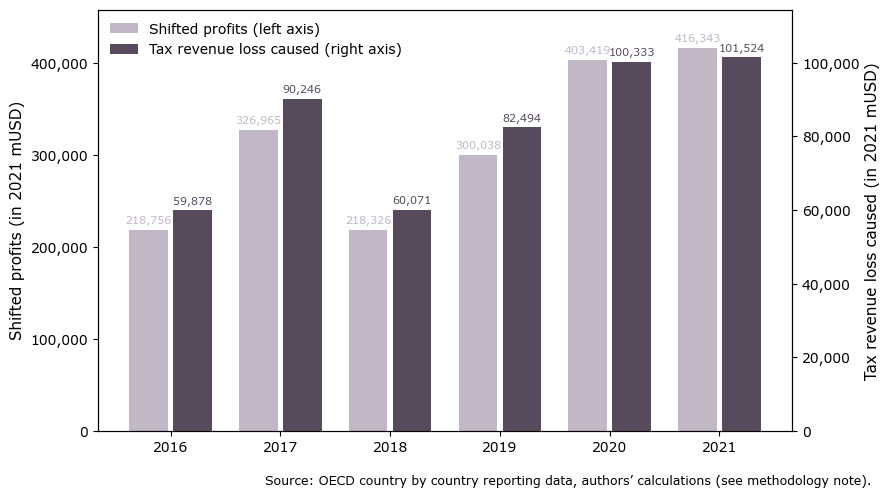

In [24]:
# --- Data prep ---
ts = (
    us_mnes_real.groupby("year")[["total_negative_misalignment", "total_tax_revenue_loss"]]
    .sum(min_count=1)
    .sort_index()
)

years = ts.index
shifted = ts["total_negative_misalignment"]
loss    = ts["total_tax_revenue_loss"]

x = np.arange(len(years))  # x positions for bars
width = 0.35               # bar width
gap = 0.05                 # extra space between bars

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(9, 5))

# Left axis: shifted profits (left)
bars1 = ax1.bar(
    x - (width/2 + gap/2), shifted, width,
    label="Shifted profits", color=COLORS["light_purple"]
)

ratio = 100_000 / 400_000  # = 0.25
left_top  = shifted.max() * 1.1
right_top = left_top * ratio

ax1.set_ylabel("Shifted profits (in 2021 mUSD)", color = "black", fontsize=11)
ax1.tick_params(axis="y", labelcolor="black")
ax1.set_ylim(0, left_top)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Right axis: tax losses (right)
ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + (width/2 + gap/2), loss, width,
    label="Tax revenue loss", color=COLORS["dark_purple"]
)
ax2.set_ylabel("Tax revenue loss caused (in 2021 mUSD)", color="black", fontsize=11)
ax2.tick_params(axis="y", labelcolor="black")
ax2.set_ylim(0, right_top)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))

# X-axis ticks/labels
ax1.set_xticks(x)
ax1.set_xticklabels(years)

# Add value labels
for bar in bars1:
    h = bar.get_height()
    ax1.annotate(f"{h:,.0f}",
                 xy=(bar.get_x() + bar.get_width() / 2, h),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha="center", va="bottom",
                 color=COLORS["light_purple"], fontsize=8)

for bar in bars2:
    h = bar.get_height()
    ax2.annotate(f"{h:,.0f}",
                 xy=(bar.get_x() + bar.get_width() / 2, h),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha="center", va="bottom",
                 color=COLORS["dark_purple"], fontsize=8)

# --- Legend indicating axis sides (NEW) ---
legend_handles = [
    Patch(facecolor=COLORS["light_purple"],      label="Shifted profits (left axis)"),
    Patch(facecolor=COLORS["dark_purple"], label="Tax revenue loss caused (right axis)"),
]
ax1.legend(handles=legend_handles, loc="upper left", frameon=False)

# --- Source note ---
plt.tight_layout(rect=(0, 0.05, 1, 1))  # leave space at the bottom for the source
fig.text(
    0.3, 0.015,
    "Source: OECD country by country reporting data, authors’ calculations (see methodology note).",
    ha="left", va="bottom", fontsize=9
)


plt.show()

# Save
fig.savefig(os.path.join(FIG_PATH, "figure_us_mnes_shifted_profits_en.png"),
            dpi=300, bbox_inches="tight")


#### Table 1: Profit shifted and losses caused by US MNEs, per suffering country

In [25]:
losses_percountry_total_real = (
    usa_mnes_percountry_real
    .groupby(["partner_jurisdiction","iso_partner","region_tjn"], as_index=False)
    .agg(
        profits_shifted_outward = ("negative_misalignment", "sum"),
        profits_shifted_inwards = ("positive_misalignment", "sum"),
        tax_revenue_loss=("tax_revenue_loss", "sum"),
        avg_pct=("tax_revenue_loss_pct_of_gvt_health_expenditure", "mean")
    )
    .rename(columns={
        "partner_jurisdiction": "Country",
        "profits_shifted_outward": "Profits shifted outward US MNEs",
        "tax_revenue_loss": "Tax revenue loss US MNEs",
        "avg_pct": "US MNEs loss share of health expenditure"
    })
    .sort_values(by="Tax revenue loss US MNEs", ascending=False)
)



Export to Overleaf

In [26]:
# --- Exclude Luxembourg first ---
filtered = losses_percountry_total_real.query("Country != 'Luxembourg'")
filtered = filtered.query("Country != 'Malta'")

# --- Top 10 selections (numeric, without Luxembourg) ---
top10_loss = filtered.nlargest(
    10, "Tax revenue loss US MNEs"
)[["Country", "Tax revenue loss US MNEs"]]

top10_share = filtered.nlargest(
    10, "US MNEs loss share of health expenditure"
)[["Country", "US MNEs loss share of health expenditure"]]

# --- Formatting helpers ---
def format_loss(df):
    out = df.copy()
    out["Tax revenue loss US MNEs"] = out["Tax revenue loss US MNEs"].apply(
        lambda x: f"{int(round(x)):,}"
    )
    return out

def format_share(df):
    out = df.copy()
    out["US MNEs loss share of health expenditure"] = out[
        "US MNEs loss share of health expenditure"
    ].apply(lambda x: f"{x*100:.1f}\\%")
    return out

# --- Exports ---
# full table with both columns (still includes Luxembourg)
format_loss(losses_percountry_total_real).pipe(format_share).to_latex(
    os.path.join(TAB_PATH, "table_loss_caused_by_usmnes_all.tex"),
    index=False, escape=False,
    column_format="lrr"  # left, right, right
)
losses_percountry_total_real.to_csv(
    os.path.join(TAB_PATH, "table_loss_caused_by_usmnes_all.csv"),
    index=False
)

# top 10 by loss: only loss column (Luxembourg excluded)
format_loss(top10_loss).to_latex(
    os.path.join(TAB_PATH, "table_loss_caused_by_usmnes_top10_by_loss.tex"),
    index=False, escape=False,
    column_format="lr"   # left, right
)

# top 10 by share: only share column (Luxembourg excluded)
format_share(top10_share).to_latex(
    os.path.join(TAB_PATH, "table_loss_caused_by_usmnes_top10_by_share.tex"),
    index=False, escape=False,
    column_format="lr"   # left, right
)

In [121]:
annextable = (
    losses_percountry_total_real
    .merge(
        recovered_by_pcbcr,
        on=["iso_partner","Country","region_tjn"],
        how="outer",                  # <-- keep all rows from both
        indicator=True                # optional: shows where each row came from
    )
)
annextable["Country"] = annextable["Country"].replace({
    "Palestinian Authority or West Bank and Gaza Strip": "Palestine",
})

In [122]:
# after your merge
mask = annextable["_merge"].eq("right_only")

annextable.loc[mask, "Country"] = (
    annextable.loc[mask, "Country"]
      .astype(str).str.rstrip()
      .str.replace(r"\s*\*$", "", regex=True)   # remove existing trailing *
      + "*"
)


In [123]:
def make_annex_table_latex(annextable: pd.DataFrame) -> str:
    cols_order = [
        "Country",
        "Profits shifted outward US MNEs",
        "Tax revenue loss US MNEs",
        "US MNEs loss share of health expenditure",
        "Profits shifted outward global MNEs",
        "Tax revenue loss global MNEs",
        "Global MNEs loss share of health expenditure",
        "Estimated tax revenue recovered if CbCR were public",
    ]
    percent_cols = ["US MNEs loss share of health expenditure", "Global MNEs loss share of health expenditure"]

    need = ["Country", "region_tjn"] + [c for c in cols_order if c != "Country"]
    df = annextable.loc[:, [c for c in need if c in annextable.columns]].copy()

    def pct_scale(series: pd.Series) -> float:
        vals = series.dropna().to_numpy()
        if vals.size == 0:
            return 100.0
        return 1.0 if (np.mean(vals > 1) > 0.5) else 100.0

    pct_scales = {c: pct_scale(df[c]) for c in percent_cols if c in df.columns}

    value_cols = [c for c in cols_order if c not in ("Country",) + tuple(percent_cols)]
    agg_map = {c: "sum" for c in value_cols if c in df.columns}
    agg_map.update({c: "mean" for c in percent_cols if c in df.columns})

    global_totals = df.agg(agg_map)
    region_totals = (df.groupby("region_tjn", dropna=False).agg(agg_map).reset_index())

    region_totals = region_totals.sort_values("region_tjn", kind="stable")
    df = df.sort_values(["region_tjn", "Country"], kind="stable")

    def fmt_money(x):
        if pd.isna(x):
            return ""
        return f"{x:,.1f}"

    def fmt_pct(x, col):
        if pd.isna(x):
            return ""
        scale = pct_scales.get(col, 100.0)
        return f"{x*scale:,.1f}\\%"

    def row_to_cells(row, bold=False):
        cells = []
        for col in cols_order:
            if col == "Country":
                txt = str(row.get(col, ""))
            elif col in percent_cols:
                txt = fmt_pct(row.get(col, np.nan), col)
            else:
                txt = fmt_money(row.get(col, np.nan))
            if bold and txt != "":
                txt = f"\\textbf{{{txt}}}"
            cells.append(txt)
        return " & ".join(cells) + " \\\\"

    def empty_row():
        return (" & ".join([""] * len(cols_order))) + " \\\\"

    region_rowcolor = "\\rowcolor{black!7}"

    lines = []

    # Global total (empty spacer + shaded total row)
    global_row = {"Country": "Total", **global_totals.to_dict()}
    lines.append(empty_row())
    lines.append(region_rowcolor)
    lines.append(row_to_cells(global_row, bold=True) + "\\hline")

    # Regions + countries
    for region, sub in df.groupby("region_tjn", dropna=False):
        region_label = str(region).strip() if pd.notna(region) else "Unknown region"
        region_norm = region_label.lower()

        lines.append(empty_row())

        # region aggregate (shaded + bold)
        reg_tot = region_totals.loc[region_totals["region_tjn"] == region].iloc[0].to_dict()
        reg_row = {"Country": region_label}
        reg_row.update({k: v for k, v in reg_tot.items() if k != "region_tjn"})

        lines.append(region_rowcolor)
        lines.append(row_to_cells(reg_row, bold=True) + "\\hline")

        # countries
        for _, r in sub.iterrows():
            lines.append(row_to_cells(r, bold=False))

    lines.append("\\hline")
    return "\n".join(lines)


In [124]:
latex_str = make_annex_table_latex(annextable)

from pathlib import Path
save_path = Path(TAB_PATH) / "table_countrylevel_data_en.tex"
save_path.parent.mkdir(parents=True, exist_ok=True)
save_path.write_text(latex_str, encoding="utf-8")

print(f"Saved to: {save_path}")


Saved to: C:\Users\aliso\Dropbox\Apps\Overleaf\SOTJ 2025\Tables\en\table_countrylevel_data_en.tex


In [125]:
annextable['Recovered as share of health expenditure'] = annextable["Global MNEs loss share of health expenditure"] * share_scalar

In [126]:
def export_annex_table_excel(annextable: pd.DataFrame, excel_path: str) -> None:
    # --- column setup (same as your LaTeX) ---
    cols_order = [
        "Country",
        "Profits shifted outward US MNEs",
        "Tax revenue loss US MNEs",
        "US MNEs loss share of health expenditure",
        "Profits shifted outward global MNEs",
        "Tax revenue loss global MNEs",
        "Global MNEs loss share of health expenditure",
        "Estimated tax revenue recovered if CbCR were public",
        'Recovered as share of health expenditure'
        
    ]
    percent_cols = [
        "US MNEs loss share of health expenditure",
        "Global MNEs loss share of health expenditure",
        'Recovered as share of health expenditure'
    ]

    # keep only needed columns + region for grouping
    need = ["Country", "region_tjn"] + [c for c in cols_order if c != "Country"]
    df = annextable.loc[:, [c for c in need if c in annextable.columns]].copy()

    # detect % scaling (0–1 vs 0–100) once
    def pct_scale(series: pd.Series) -> float:
        vals = series.dropna().to_numpy()
        if vals.size == 0:
            return 100.0
        return 1.0 if (np.mean(vals > 1) > 0.5) else 100.0

    pct_scales = {c: pct_scale(df[c]) for c in percent_cols if c in df.columns}

    # aggregation: sum money columns, mean percentage columns
    value_cols = [c for c in cols_order if c not in ("Country",) + tuple(percent_cols)]
    agg_map = {c: "sum" for c in value_cols if c in df.columns}
    agg_map.update({c: "mean" for c in percent_cols if c in df.columns})

    # compute totals
    global_totals = df.agg(agg_map)
    region_totals = df.groupby("region_tjn", dropna=False).agg(agg_map).reset_index()

    # sort like LaTeX
    region_totals = region_totals.sort_values("region_tjn", kind="stable")
    df = df.sort_values(["region_tjn", "Country"], kind="stable")

    # formatters (Excel: put numbers, but format % as percentages 0–1)
    def as_percent(x, col):
        if pd.isna(x):
            return np.nan
        scale = pct_scales.get(col, 100.0)
        # return as fraction for Excel percentage cell format (e.g. 0.352 for 35.2%)
        return (x*scale)/100.0

    # Build rows in display order: empty spacer, Total, then for each region an empty spacer, region row, then countries
    rows = []

    # Helper: append a row dict with a "Level" tag for styling (“total”, “region”, “country”, “spacer”)
    def add_row(level, label=None, src=None):
        rec = {c: np.nan for c in cols_order}
        rec["Country"] = label if label is not None else ""
        if src is not None:
            for c in cols_order:
                if c == "Country": 
                    continue
                if c in percent_cols:
                    rec[c] = as_percent(src.get(c, np.nan), c)
                else:
                    rec[c] = src.get(c, np.nan)
        rec["_Level"] = level
        rows.append(rec)

    # spacer + Global total
    add_row("spacer")
    add_row("total", "Total", global_totals.to_dict())

    # regions
    for region, sub in df.groupby("region_tjn", dropna=False):
        label = str(region).strip() if pd.notna(region) else "Unknown region"
        # spacer then region header
        add_row("spacer")
        reg_dict = region_totals.loc[region_totals["region_tjn"] == region].iloc[0].to_dict()
        reg_dict.pop("region_tjn", None)
        add_row("region", label, reg_dict)
        # countries
        for _, r in sub.iterrows():
            add_row("country", r["Country"], r.to_dict())

    out_df = pd.DataFrame(rows)

    # Write to Excel with light styling for totals/regions
    # Requires xlsxwriter installed
    os.makedirs(os.path.dirname(excel_path), exist_ok=True)
    with pd.ExcelWriter(excel_path, engine="xlsxwriter") as writer:
        sheet = "Country-level results"
        # write data (including _Level)
        out_df.to_excel(writer, sheet_name=sheet, index=False)

        wb  = writer.book
        ws  = writer.sheets[sheet]

        # formats
        fmt_pct   = wb.add_format({"num_format": "0.0%", "align": "center"})
        fmt_money = wb.add_format({"num_format": "#,##0.0", "align": "right"})
        fmt_text  = wb.add_format({"align": "left"})
        fmt_shade_bold = wb.add_format({"bold": True, "bg_color": "#EEEEEE"})
        fmt_shade_bold_right = wb.add_format({"bold": True, "bg_color": "#EEEEEE", "align": "right"})
        fmt_shade_bold_center = wb.add_format({"bold": True, "bg_color": "#EEEEEE", "align": "center"})

        # column indices
        col_idx = {c: i for i, c in enumerate(out_df.columns)}
        # set column widths + formats (skip _Level)
        ws.set_column(col_idx["Country"], col_idx["Country"], 28, fmt_text)
        for c in cols_order[1:]:
            if c in percent_cols:
                ws.set_column(col_idx[c], col_idx[c], 14, fmt_pct)
            else:
                ws.set_column(col_idx[c], col_idx[c], 16, fmt_money)

        # apply shading/bold to Total & Region rows; leave spacer blank
        level_col = col_idx["_Level"]
        nrows, ncols = out_df.shape
        for r in range(1, nrows+1):  # +1 for header row offset
            level = out_df.iloc[r-1, level_col]
            if level in ("total", "region"):
                # apply bold + shade across visible columns (exclude _Level)
                ws.set_row(r, None, None)  # ensure row exists
                # Country cell left-align bold+shade
                ws.write(r, col_idx["Country"], out_df.iloc[r-1, col_idx["Country"]], fmt_shade_bold)
                # the rest: percent center, money right
                for c in cols_order[1:]:
                    val = out_df.iloc[r-1, col_idx[c]]
                    if c in percent_cols:
                        ws.write(r, col_idx[c], val, fmt_shade_bold_center)
                    else:
                        ws.write(r, col_idx[c], val, fmt_shade_bold_right)
            elif level == "spacer":
                ws.set_row(r, 6)  # tiny spacer height

        # Hide the helper column
        ws.set_column(level_col, level_col, None, None, {"hidden": True})

    print(f"Excel written to: {excel_path}")

# ------- Example usage (alongside your LaTeX save) -------
# latex_str = make_annex_table_latex(annextable)
# with open(os.path.join(TAB_PATH, "table_countrylevel_data_en.tex"), "w", encoding="utf-8") as f:
#     f.write(latex_str)

excel_out = "C:/Users/aliso/Tax Justice Network Ltd/TJN - Shared Documents/Research team/Projects long-term/SOTJ/SOTJ_2025/Results_countrylevel.xlsx"
export_annex_table_excel(annextable, excel_out)


Excel written to: C:/Users/aliso/Tax Justice Network Ltd/TJN - Shared Documents/Research team/Projects long-term/SOTJ/SOTJ_2025/Results_countrylevel.xlsx


### Figure 2: Distribution of losses

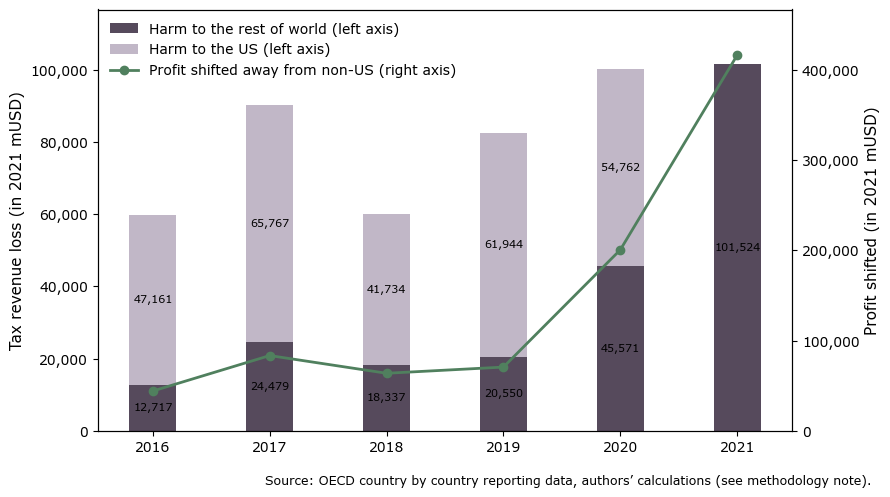

In [127]:
# ---------- Prep ----------
mask_us = usa_mnes_percountry_real["partner_jurisdiction"].eq("United States")
us_loss  = usa_mnes_percountry_real.loc[mask_us].groupby("year")["tax_revenue_loss"].sum(min_count=1)
row_loss = usa_mnes_percountry_real.loc[~mask_us].groupby("year")["tax_revenue_loss"].sum(min_count=1)

# Profit shifted AWAY FROM NON-US only (deflated): sum negative_misalignment for non-US countries
shifted_row = (
    usa_mnes_percountry_real.loc[~mask_us]
    .groupby("year")["negative_misalignment"]
    .sum(min_count=1)
)

# Common ordered years (2016–2021)
years = list(range(2016, 2021 + 1))
US    = us_loss.reindex(years, fill_value=0).astype(float)
ROW   = row_loss.reindex(years, fill_value=0).astype(float)
TOT   = (US + ROW)
SHIFT = shifted_row.reindex(years, fill_value=0).astype(float)

# ---------- Plot ----------
x = np.arange(len(years))
bar_width = 0.4

fig, ax1 = plt.subplots(figsize=(9, 5))

# Stacked bars (left axis): tax losses
bars_row = ax1.bar(
    x, ROW.values, bar_width,
    label="Harm to the rest of world (left axis)",
    color=COLORS["dark_purple"]
)
bars_us  = ax1.bar(
    x, US.values,  bar_width, bottom=ROW.values,
    label="Harm to the US (left axis)",
    color=COLORS["light_purple"]
)

ax1.set_ylabel("Tax revenue loss (in 2021 mUSD)", fontsize=11, color="black")
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))

# Match scales: 100,000 (left) == 400,000 (right)
left_top  = 1.15 * float(TOT.max()) if len(TOT) else 1.0
right_top = left_top * 4.0
ax1.set_ylim(0, left_top)

# Line (right axis): profit shifted away from non-US only (no point labels)
ax2 = ax1.twinx()
ax2.plot(
    x, SHIFT.values,
    marker="o", linewidth=2, color=COLORS["earthgreen"],
    label="Profit shifted away from non-US (right axis)"
)
ax2.set_ylabel("Profit shifted (in 2021 mUSD)", fontsize=11, color="black")
ax2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax2.set_ylim(0, right_top)

# --- One combined legend from both axes (no overwrite) ---
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", frameon=False)

# Subtotals inside each bar segment (kept)
for br, bu, rowv, usv in zip(bars_row, bars_us, ROW.values, US.values):
    if rowv > 0:
        ax1.text(
            br.get_x() + br.get_width()/2, rowv/2, f"{rowv:,.0f}",
            ha="center", va="center", fontsize=8
        )
    if usv > 0:
        ax1.text(
            bu.get_x() + bu.get_width()/2, rowv + usv/2, f"{usv:,.0f}",
            ha="center", va="center", fontsize=8
        )

plt.tight_layout(rect=(0, 0.05, 1, 1))  # leave space at the bottom for the source
fig.text(
    0.3, 0.015,
    "Source: OECD country by country reporting data, authors’ calculations (see methodology note).",
    ha="left", va="bottom", fontsize=9
)

plt.show()

# ---------- Save ----------
fig.savefig(
    os.path.join(FIG_PATH, "figure_distribution_harm_usmnes_en.png"),
    dpi=300, bbox_inches="tight"
)
fig.savefig(
    os.path.join(FIG_PATH2, "figure_distribution_harm_usmnes_en.png"),
    dpi=300, bbox_inches="tight"
)

Report shares of harm suffered by US

In [128]:
# US vs RoW totals per year (already deflated to 2021 USD)
mask_us = usa_mnes_percountry_real["partner_jurisdiction"].eq("United States")
US  = usa_mnes_percountry_real.loc[mask_us].groupby("year")["tax_revenue_loss"].sum(min_count=1)
TOT = usa_mnes_percountry_real.groupby("year")["tax_revenue_loss"].sum(min_count=1)

# US share per year
share_us = (US / TOT).replace([np.inf, -np.inf], np.nan)

# Focus window 2016–2020
win = range(2016, 2021)
share_us_16_20 = share_us.reindex(win)

# Simple average of yearly shares
avg_share_simple = share_us_16_20.mean(skipna=True)

# Loss-weighted average share over 2016–2020
US_16_20  = US.reindex(win).fillna(0)
TOT_16_20 = TOT.reindex(win).fillna(0)
avg_share_weighted = (US_16_20.sum() / TOT_16_20.sum()) if TOT_16_20.sum() else np.nan

# Pretty print for pasting into text
print(share_us_16_20.apply(lambda x: f"{x*100:.1f}%" if pd.notna(x) else "N/A").to_string())
print("US share of losses, 2016–2020 (simple avg): "
      f"{avg_share_simple*100:.1f}%")
print("US share of losses, 2016–2020 (loss-weighted avg): "
      f"{avg_share_weighted*100:.1f}%")

year
2016    78.8%
2017    72.9%
2018    69.5%
2019    75.1%
2020    54.6%
US share of losses, 2016–2020 (simple avg): 70.2%
US share of losses, 2016–2020 (loss-weighted avg): 69.0%


 Percentage of profit shifting abroad

In [129]:
# --- % of total profits shifted from non-US countries ---
# Numerator: shifted out of non-US countries
row_neg_per_year = (
    usa_mnes_percountry_real.loc[~usa_mnes_percountry_real["partner_jurisdiction"].eq("United States")]
    .groupby("year")["negative_misalignment"]
    .sum(min_count=1)
    .sort_index()
)

# Denominator: total reported profit (US + non-US)
total_reported_per_year = (
    usa_mnes_percountry_real.groupby("year")["reported_profit"]
    .sum(min_count=1)
    .sort_index()
)

pct_row_of_total = (row_neg_per_year / total_reported_per_year) * 100

# Nicely formatted summary (e.g., for your text)
summary_df = (
    pct_row_of_total.rename("% of total profits shifted from non-US countries")
    .reset_index()
)
summary_df["% of total profits shifted from non-US countries"] = summary_df[
    "% of total profits shifted from non-US countries"
].apply(lambda x: f"{x:.1f}%")

print(summary_df)


   year % of total profits shifted from non-US countries
0  2016                                             6.5%
1  2017                                             6.9%
2  2018                                             7.5%
3  2019                                             8.4%
4  2020                                            12.8%
5  2021                                            16.2%


#### Figure 3: Money hidden offshore

In [130]:
# -------- paths / params --------
ow_path = Path(r"C:/Users/aliso/Tax Justice Network Ltd/TJN - Shared Documents/Research team/Projects long-term/Offshore wealth/Tables/SOTJ2024 results offshore wealth - all years.csv")
countries = ["Cayman Islands", "United Kingdom", "United States"]
years_full = list(range(2016, 2022))

ow = pd.read_csv(ow_path)

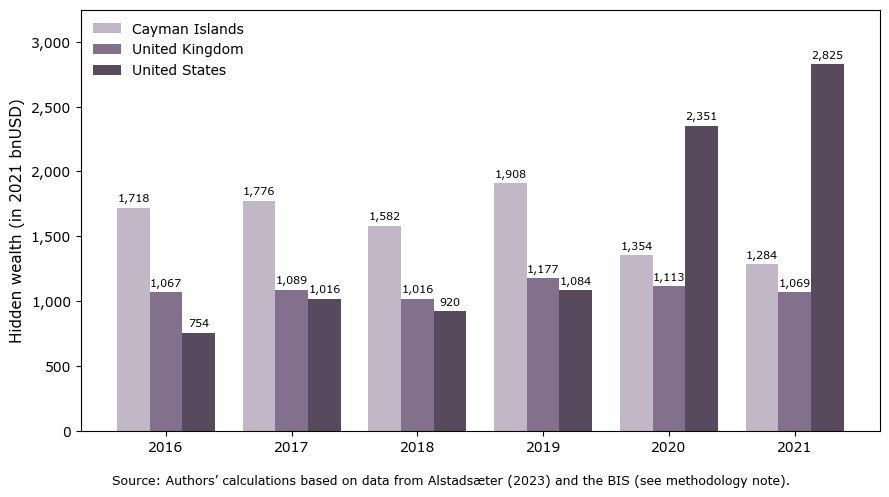

In [131]:
# -------- paths / params --------
ow_path = Path(r"C:/Users/aliso/Tax Justice Network Ltd/TJN - Shared Documents/Research team/Projects long-term/Offshore wealth/Tables/SOTJ2024 results offshore wealth - all years.csv")
countries = ["Cayman Islands", "United Kingdom", "United States"]
years_full = list(range(2016, 2022))

ow = pd.read_csv(ow_path)

df = ow[["year", "country", "inward_ow"]].copy()

# -------- deflate to 2021 USD --------
df_real = deflate_to_base_dataset(df, cpi_index, year_col="year", base_year=2021, extra_exclude=["country"])

# -------- pivot to year × country --------
ts = (
    df_real.pivot_table(index="year", columns="country", values="inward_ow", aggfunc="sum")
          .reindex(years_full)
          .fillna(0.0)
)

years = ts.index.tolist()
CAY = ts["Cayman Islands"].to_numpy(float)
UK  = ts["United Kingdom"].to_numpy(float)
US  = ts["United States"].to_numpy(float)


# --- Plot grouped bars without overlap ---
x = np.arange(len(years))

# choose a total width for the whole 3-bar group at each year (< 1.0 leaves space between groups)
total_width = 0.78
n_series = 3
width = total_width / n_series  # individual bar width

# centered offsets for each series: [-w, 0, +w] scaled to total_width
offsets = (-total_width/2 + width/2) + np.arange(n_series) * width

fig, ax = plt.subplots(figsize=(9, 5))

c_cay = COLORS.get("light_purple", "#c8a2c8")
c_uk  = COLORS.get("purple", COLORS.get("medium_purple", "#8b6fb3"))
c_us  = COLORS.get("dark_purple", "#4b2e83")

b1 = ax.bar(x + offsets[0], CAY, width, label="Cayman Islands", color=c_cay)
b2 = ax.bar(x + offsets[1], UK,  width, label="United Kingdom", color=c_uk)
b3 = ax.bar(x + offsets[2], US,  width, label="United States",  color=c_us)

ax.set_ylabel("Hidden wealth (in 2021 bnUSD)", fontsize=11, color="black")
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_ylim(0, 1.15 * max(np.max(CAY), np.max(UK), np.max(US)))
ax.legend(loc="upper left", frameon=False)

# Value labels
def add_labels(bars):
    for b in bars:
        h = b.get_height()
        if np.isfinite(h) and h > 0:
            ax.annotate(f"{h:,.0f}",
                        (b.get_x() + b.get_width()/2, h),
                        xytext=(0, 3), textcoords="offset points",
                        ha="center", va="bottom", fontsize=8)

add_labels(b1); add_labels(b2); add_labels(b3)

plt.tight_layout(rect=(0, 0.05, 1, 1))  # leave space at the bottom for the source
fig.text(
    0.13, 0.015,
    "Source: Authors’ calculations based on data from Alstadsæter (2023) and the BIS (see methodology note).",
    ha="left", va="bottom", fontsize=9
)

plt.show()

fig.savefig(os.path.join(FIG_PATH, "figure_inward_ow_cay_uk_us_en.png"),
            dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(FIG_PATH2, "figure_inward_ow_cay_uk_us_en.png"),
            dpi=300, bbox_inches="tight")



#### Figure 4: US ETRs of all and Big Tech

In [132]:
compustat_all = pd.read_csv('../output/2025/tables/us_mnes_under_trump_all.csv')
compustat_bigtech = pd.read_csv('../output/2025/tables/us_mnes_under_trump_bigtech.csv')

In [133]:
def plot_domestic_etrs(
    compustat_all: pd.DataFrame,
    bigtech_df: pd.DataFrame,
    *,
    etr_central: str = "median",   # "median" or "mean"
    year_min: int = 2016,
    year_max: int = 2024,
    figsize=(9,5),
    top_pad: float = 0.25,         # headroom above max (% of max)
    # optional: per-year label vertical nudges (fraction of ymax). Negative => below point.
    label_dy: dict | None = None,  # e.g., {("BigTech",2016):-0.035, ("All",2024):0.02}
):
    """
    Plots domestic ETR for US MNEs vs BigTech (2016–2024), with non-overlapping labels.
    Requires global COLORS dict and add_tcja_marker(ax, years, ...) utility.
    Returns (fig, ax, d_tbl).
    """
    # Default label offsets if none provided
    if label_dy is None:
        # Put BigTech's 2016 label below the point to avoid overlap; others above.
        label_dy = {
            ("BigTech", 2016): -0.035,
            ("All",     2016):  0.02,
            ("All",     2024):  0.02,
            ("BigTech", 2024):  0.02,
        }

    # Column with domestic ETR
    col_dom = "med_etr_domestic" if etr_central == "median" else "mean_etr_domestic"

    # Filter windows
    a = compustat_all[(compustat_all["year"] >= year_min) & (compustat_all["year"] <= year_max)].copy()
    b = bigtech_df[(bigtech_df["year"] >= max(2016, year_min)) & (bigtech_df["year"] <= year_max)].copy()  # no 2015 for BigTech

    # Keep only needed columns
    a = a[["year", col_dom]].rename(columns={col_dom: "etr_dom_all"}).sort_values("year")
    b = b[["year", col_dom]].rename(columns={col_dom: "etr_dom_bigtech"}).sort_values("year")

    # Union of years so both lines share the same x-axis
    years = np.union1d(a["year"].to_numpy(), b["year"].to_numpy())
    d = pd.DataFrame({"year": years}).merge(a, on="year", how="left").merge(b, on="year", how="left")

    # Helper: convert to percent if series seems in 0-1 form
    def to_percent(series: pd.Series) -> np.ndarray:
        arr = series.to_numpy(dtype=float)
        with np.errstate(all='ignore'):
            scale_is_percent = np.nanmedian(np.abs(arr)) > 1.5
        return arr if scale_is_percent else arr * 100.0

    y_all = to_percent(d["etr_dom_all"])
    y_bt  = to_percent(d["etr_dom_bigtech"])

    # ---- BigTech 2017 special handling: use avg(2016, 2018) if both exist ----
    yrs = d["year"].to_numpy()
    y_bt_adj = y_bt.copy()
    has_est_2017 = False
    if 2017 in yrs:
        i17 = np.where(yrs == 2017)[0][0]
        i16 = np.where(yrs == 2016)[0][0] if 2016 in yrs else None
        i18 = np.where(yrs == 2018)[0][0] if 2018 in yrs else None
        if i16 is not None and i18 is not None and np.isfinite(y_bt[i16]) and np.isfinite(y_bt[i18]):
            y_bt_adj[i17] = 0.5 * (y_bt[i16] + y_bt[i18])
            has_est_2017 = True

    # X positions
    x = np.arange(len(yrs))

    fig, ax = plt.subplots(figsize=figsize)

    # Plot US MNEs domestic ETR (solid)
    line_all, = ax.plot(
        x, y_all, marker="o", linewidth=2,
        label="Effective tax rate US corporations paid in the US",
        color=COLORS["dark_purple"]
    )

    # Plot BigTech domestic ETR as a solid line; make ONLY 2017 marker hollow if estimated
    line_bt, = ax.plot(
        x, (y_bt_adj if has_est_2017 else y_bt), marker="o", linewidth=2,
        label="Effective tax rate Big Tech have paid in the US",
        color=COLORS["light_purple"]
    )
    if has_est_2017:
        # Overplot hollow marker at 2017
        ax.plot(
            x[i17], y_bt_adj[i17],
            marker="o", markersize=6,
            markerfacecolor="white",
            markeredgecolor=COLORS["light_purple"],
            markeredgewidth=2
        )

    # Axes & headroom
    ax.set_xticks(x)
    ax.set_xticklabels(yrs)
    ax.set_ylabel("ETR (%)")

    def _max_finite(*arrays):
        vals = np.hstack([np.asarray(a) for a in arrays]) if arrays else np.array([])
        vals = vals[np.isfinite(vals)]
        return float(vals.max()) if vals.size else 0.0

    ymax = _max_finite(y_all, y_bt_adj if has_est_2017 else y_bt)
    ax.set_ylim(0, (1 + top_pad) * ymax if ymax > 0 else 1.0)

    # --- TCJA vertical line & label (supports fractional years) ---
    add_tcja_marker(
        ax, years=yrs, tcja_year=2017.5, pad_frac=0.15,
        color=COLORS["purple"], linestyle=":", linewidth=2.0,
        show_label=True,
        line_top_frac=0.86   # << stops the dashed line under the legend area
    )

    # --- Label helper with vertical offset in fraction of ymax ---
    def label_point(year, y_array, color, *, dy_frac=0.02):
        """
        Place a data label at 'year'. dy_frac is a fraction of ymax; negative puts the label below the point.
        """
        if year in yrs:
            idx = np.where(yrs == year)[0][0]
            yv = y_array[idx]
            if np.isfinite(yv):
                dy = dy_frac * ymax
                ax.text(
                    x[idx],
                    yv + dy,
                    f"{yv:.1f}%",
                    ha="center",
                    va=("bottom" if dy_frac >= 0 else "top"),
                    fontsize=9,
                    color=color,
                    clip_on=True,
                )

    # --- Apply labels (uses label_dy overrides) ---
    def get_dy(series_key: str, year: int, default: float = 0.02) -> float:
        return label_dy.get((series_key, year), default)

    # 2024 labels (both series)
    if 2024 in yrs:
        label_point(2024, y_all, COLORS["dark_purple"], dy_frac=get_dy("All", 2024))
        label_point(2024, y_bt_adj if has_est_2017 else y_bt, COLORS["light_purple"], dy_frac=get_dy("BigTech", 2024))

    # 2016 labels: US-all above, BigTech below (by default via label_dy)
    if 2016 in yrs:
        label_point(2016, y_all, COLORS["dark_purple"],  dy_frac=get_dy("All", 2016))
        label_point(2016, y_bt_adj if has_est_2017 else y_bt, COLORS["light_purple"], dy_frac=get_dy("BigTech", 2016))

    # Legend
    ax.legend(handles=[line_all, line_bt], loc="upper left", frameon=False)

    fig.tight_layout(rect=(0, 0.05, 1, 1))  # leave space at the bottom for the source
    fig.text(
        0.6, 0.015,
        "Source: Compustat North America, authors’ calculations.",
        ha="left", va="bottom", fontsize=9
    )

    # Table to return
    d_tbl = (
        pd.DataFrame({
            "year": yrs,
            "ETR US corporations (%, median)" if etr_central=="median" else "ETR US corporations (%, mean)": np.round(y_all, 1),
            "ETR BigTech (%, median)" if etr_central=="median" else "ETR BigTech (%, mean)": np.round(y_bt_adj if has_est_2017 else y_bt, 1)
        })
        .sort_values("year")
        .reset_index(drop=True)
    )
    if has_est_2017:
        d_tbl["note"] = np.where(d_tbl["year"] == 2017, "BigTech 2017 = avg(2016,2018)", "")

    return fig, ax, d_tbl


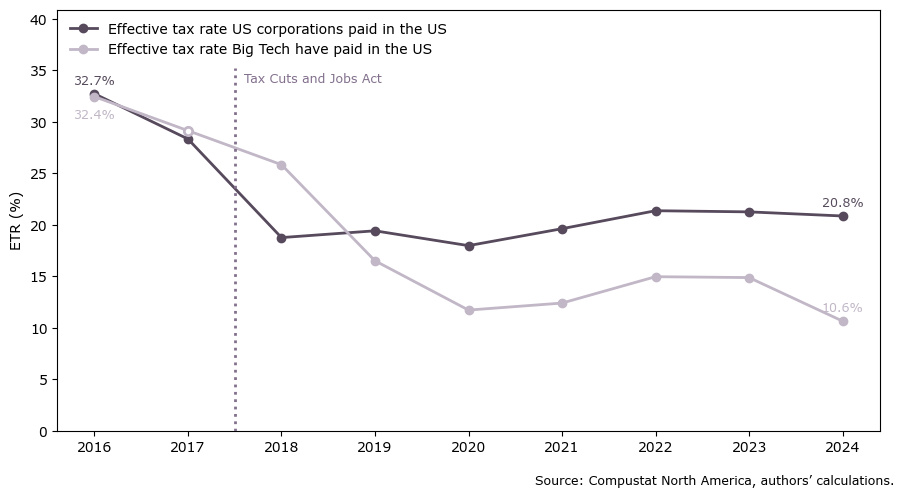

In [134]:
# ETR lines figure (Domestic/Foreign from compustat_all + BigTech Domestic):
fig2, ax2, d_tbl = plot_domestic_etrs(
    compustat_all, compustat_bigtech,
    etr_central="median", year_min=2016, year_max=2024
)
fig2.savefig(os.path.join(FIG_PATH,"figure_etrs_us_en.png"), dpi=300, bbox_inches="tight")
fig2.savefig(os.path.join(FIG_PATH2,"figure_etrs_us_en.png"), dpi=300, bbox_inches="tight")

#### Table 2: ETR of Big Techs 2016 versus 2024

In [135]:
compustat_bigtech_panel = pd.read_csv('../output/2025/tables/us_mnes_under_trump_bigtech_panel.csv')

In [136]:

def make_bigtech_etr_table(
    bigtech_panel: pd.DataFrame,
    out_tex_path: str = "Tables/en/table_bigtech_etrs_2016_2024.tex",
    add_average_row: bool = True
):
    df = bigtech_panel.copy()

    # Canonical names
    t = df.assign(
        TIC=df["tic"].astype(str).str.upper(),
        NAME=df["conm"].astype(str).str.upper()
    )

    def canonical_brand(row):
        tic, name = row["TIC"], row["NAME"]
        if "APPLE" in name or tic == "AAPL": return "Apple"
        if "MICROSOFT" in name or tic == "MSFT": return "Microsoft"
        if "ALPHABET" in name or tic in ("GOOGL","GOOG"): return "Alphabet / Google"
        if "AMAZON" in name or tic == "AMZN": return "Amazon"
        if "META" in name or "FACEBOOK" in name or tic in ("META","FB"): return "Meta / Facebook"
        return f"{row['conm']} ({row['tic']})"

    t["Company"] = t.apply(canonical_brand, axis=1)

    # Years
    t["year"] = pd.to_numeric(t["year"], errors="coerce").astype("Int64")
    t = t[t["year"].isin([2016, 2024])]

    # ETR to percent if needed
    def to_percent(s: pd.Series) -> pd.Series:
        vals = pd.to_numeric(s, errors="coerce")
        with np.errstate(all="ignore"):
            is_percent = np.nanmedian(np.abs(vals.to_numpy())) > 1.5
        return vals if is_percent else vals * 100.0

    t["etr_domestic"] = to_percent(t["etr_domestic"])
    t["etr_foreign"]  = to_percent(t["etr_foreign"])

    # Average duplicates within company-year
    g = (t.groupby(["Company","year"], as_index=False)[["etr_domestic","etr_foreign"]]
           .mean())

    # Pivot (order: Domestic 2016, 2024; Foreign 2016, 2024)
    desired_order = ["Alphabet / Google", "Amazon", "Apple", "Meta / Facebook", "Microsoft"]
    pivot = (g.pivot(index="Company", columns="year", values=["etr_domestic","etr_foreign"])
               .reindex(desired_order))

    # Ensure columns exist and ordered
    cols = pd.MultiIndex.from_tuples([
        ("etr_domestic", 2016), ("etr_domestic", 2024),
        ("etr_foreign",  2016), ("etr_foreign",  2024)
    ])
    for c in cols:
        if c not in pivot.columns:
            pivot[c] = np.nan
    pivot = pivot[cols]

    # Optional average row
    if add_average_row:
        avg = pivot.mean(axis=0, skipna=True).to_frame().T
        avg.index = ["Average"]
        pivot = pd.concat([pivot, avg], axis=0)

    # Format helpers
    def fmt(x):
        return "–" if pd.isna(x) else f"{x:.1f}\\%"

    def latex_escape(s: str) -> str:
        # Minimal escaping for &, %, _, #, $
        rep = {'&': r'\&', '%': r'\%', '_': r'\_', '#': r'\#', '$': r'\$'}
        for k,v in rep.items(): s = s.replace(k,v)
        return s

    # Build tabular manually to control header
    lines = []
    lines.append(r"\begin{tabular}{lcccc}")
    lines.append(r"\toprule")
    # Your requested header (spanning cols 2–5)
    lines.append(r"& \multicolumn{4}{c}{Effective tax rate paid} \\")
    lines.append(r"\cmidrule(lr){2-5}")
    lines.append(r"& \multicolumn{2}{c}{in the US} & \multicolumn{2}{c}{abroad} \\")
    lines.append(r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}")
    lines.append(r"Company & 2016 & 2024 & 2016 & 2024 \\")
    lines.append(r"\midrule")

    for company, row in pivot.iterrows():
        c = latex_escape(str(company))
        d16 = fmt(row[("etr_domestic", 2016)])
        d24 = fmt(row[("etr_domestic", 2024)])
        f16 = fmt(row[("etr_foreign",  2016)])
        f24 = fmt(row[("etr_foreign",  2024)])
        lines.append(f"{c} & {d16} & {d24} & {f16} & {f24} \\\\")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")

    latex = "\n".join(lines)
    with open(out_tex_path, "w", encoding="utf-8") as f:
        f.write(latex)

    return pivot, out_tex_path


In [137]:
# bigtech_panel is your DataFrame with the listed columns
table_df, tex_path = make_bigtech_etr_table(
    compustat_bigtech_panel, out_tex_path=os.path.join(TAB_PATH,"table_bigtech_etrs_2016_2024.tex")
)
print(table_df) 

                  etr_domestic            etr_foreign           
year                      2016       2024        2016       2024
Alphabet / Google    31.247920  15.854584    7.551525  21.824687
Amazon               31.399692  10.644583         NaN  40.062997
Apple                66.826164   8.485439    5.201946  33.415265
Meta / Facebook      33.464196   8.429049    2.764228  62.740106
Microsoft                  NaN  14.885666    9.663280  22.917084
Average              40.734493  11.659864    6.295245  36.192028


#### Figure 5: Profits booked at home and abroad Big Tech

In [138]:
def plot_bigtech_company_shares(
    panel_df: pd.DataFrame,
    *,
    year_min: int = 2016,
    year_max: int = 2024,
    figsize=(10, 5.5),
    headroom_pp: float = 4,
    kind: str = "bar"
):
    """
    Per-company shares of pre-tax profits recorded in the US for Big Tech companies,
    excluding Amazon.com Inc.
    """
    cols_needed = {"year", "conm", "share_pretax_domestic"}
    missing = cols_needed - set(panel_df.columns)
    if missing:
        raise ValueError(f"panel_df missing columns: {missing}")

    # Exclude Amazon.com Inc
    df = panel_df.loc[
        (panel_df["year"] >= year_min) &
        (panel_df["year"] <= year_max) &
        (panel_df["conm"].str.lower() != "amazon.com inc"),
        ["year", "conm", "share_pretax_domestic"]
    ].copy()

    # Rename companies
    rename_map = {
        "ALPHABET INC": "Google",
        "APPLE INC": "Apple",
        "META PLATFORMS INC": "Meta/Facebook",
        "MICROSOFT CORP": "Microsoft"
    }
    df["conm"] = df["conm"].replace(rename_map)

    # Pivot to year × company
    df_pivot = df.pivot(index="year", columns="conm", values="share_pretax_domestic")

    # Your palette
    PALETTE = [
        COLORS.get("purple", "#564a5c"),
        COLORS.get("light_purple", "#c1b7c7"),
        COLORS["brown"],
        COLORS["dark_purple"],
    ]

    fig, ax = plt.subplots(figsize=figsize)

    if kind == "bar":
        df_pivot.plot(
            kind="bar",
            ax=ax,
            color=PALETTE[: len(df_pivot.columns)],
            width=0.8,   # adds spacing between bars
        )
    elif kind == "line":
        df_pivot.plot(
            kind="line",
            ax=ax,
            color=PALETTE[: len(df_pivot.columns)],
            marker="o"
        )
    else:
        raise ValueError("kind must be 'bar' or 'line'")
    
    # Derive the year labels (from the pivot index) and their x-positions
    years = df_pivot.index.to_numpy(dtype=float)
    x = np.arange(len(years), dtype=float)

    # Add the TCJA marker using the correct axis and coordinates
    add_tcja_marker(
        ax,
        years=years,
        x_positions=x,
        tcja_year=2017.5,
        color=COLORS["purple"],
        linestyle=":",
        linewidth=2.0,
        show_label=True,
    )



    # Labels and formatting
    ax.set_ylabel("Share of pretax profits in the US")
    ax.set_xlabel("")
    ax.legend(title="")

    return fig, ax


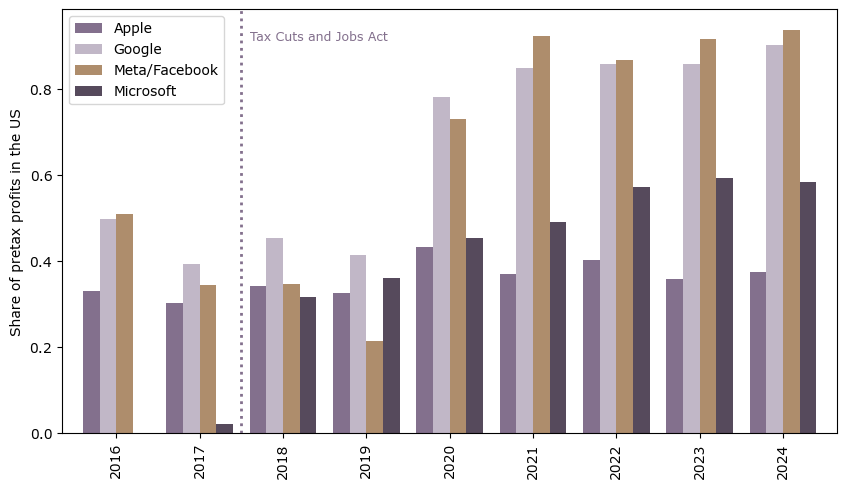

In [139]:
fig, ax = plot_bigtech_company_shares(
    compustat_bigtech_panel,
    year_min=2016, year_max=2024,
    kind="bar"
)
fig.savefig(os.path.join(FIG_PATH, "figure_bigtech_us_profit_shares_en.png"),
            dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(FIG_PATH2, "figure_bigtech_us_profit_shares_en.png"),
            dpi=300, bbox_inches="tight")

#### Figure 6: Substitution of tax havens

In [140]:
def load_cbcr_us_parents(csv_path: str) -> pd.DataFrame:
    """
    Load CbCR, keep only US-headquartered groups (iso_parent == 'USA').
    - Uppercase ISO codes
    - Drop 'WXD' (world-excluding-domestic) partner rows
    - Use existing 'is_us_partner' if present; else derive from iso_partner == 'USA'
    - Coerce relevant columns to numeric
    """
    df = pd.read_csv(csv_path)

    # Robust strings
    for col in ["iso_parent", "iso_partner"]:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")
        df[col] = df[col].astype(str).str.upper()

    # Filter: US parents
    df = df.loc[df["iso_parent"] == "USA"].copy()

    # Drop WXD (world-excluding-domestic) from partner locations
    df = df[df["iso_partner"] != "WXD"].copy()

    # US-partner flag: prefer existing, else derive
    if "is_us_partner" in df.columns:
        df["is_us_partner"] = df["is_us_partner"].astype(bool)
    else:
        df["is_us_partner"] = (df["iso_partner"] == "USA")

    # Year numeric
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

    # Coerce relevant numeric columns
    to_num = [
        "related_party_revenues",
        "holding_or_managing_ip",
        "internal_finance",
        "n_employees",
        "payroll",
        # (optional, often needed later)
        "profit_loss_before_income_tax",
        "adjusted_profit_loss_before_income_tax",
        "profit_loss_before_income_tax_corrected",
    ]
    for c in to_num:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
        else:
            # Only enforce presence for the first five you listed explicitly
            if c in {"related_party_revenues","holding_or_managing_ip","internal_finance","n_employees","payroll"}:
                raise ValueError(f"Missing required column: {c}")

    return df


In [141]:
cbcr_path = r"../data/2025/final/cbcr_dataset_total_allsubgroups.csv"
cbcr_all = pd.read_csv(cbcr_path)  # all countries
cbcr_us = load_cbcr_us_parents(cbcr_path) 

In [142]:
parents_2021 = (
    cbcr_all.assign(year=pd.to_numeric(cbcr_all['year'], errors='coerce'))
            .loc[lambda d: d['year'] == 2021, 'parent_jurisdiction']
            .astype(str).str.strip()
            .replace('', np.nan).dropna()
            .drop_duplicates()
            .sort_values()
            .tolist()
)

# Optional: see how many and preview
len(parents_2021), parents_2021[:10]


(52,
 ['Argentina',
  'Australia',
  'Austria',
  'Azerbaijan',
  'Bahrain',
  'Belgium',
  'Bermuda',
  'Brazil',
  'Bulgaria',
  'Canada'])

In [143]:
# 1) Clean year and filter 2021
df = cbcr_all.copy()
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df.loc[df['year'] == 2021].copy()

# 2) Clean parent_jurisdiction (trim, fix encodings)
fix_map = {
    "China (Peopleâ€™s Republic of)": "China (People’s Republic of)",
    "TÃ¼rkiye": "Türkiye",
    # (optional) other common fixes:
    "Czech Republic": "Czechia",
}
df['parent_jurisdiction'] = (
    df['parent_jurisdiction']
      .astype(str).str.strip()
      .replace(fix_map)
      .replace({'': np.nan})
)

# 3) Count rows per parent_jurisdiction
counts_2021 = (
    df.groupby('parent_jurisdiction', dropna=False)
      .size()
      .reset_index(name='n_rows')
      .sort_values(['n_rows','parent_jurisdiction'], ascending=[False, True])
      .reset_index(drop=True)
)

# Peek
counts_2021.head()


,parent_jurisdiction,n_rows
0,Germany,168
1,United Arab Emirates,151
2,Romania,148
3,Hong Kong (China),145
4,Japan,143


In [144]:
# Reuse your brand colors if defined
COLORS = globals().get("COLORS", {
    "red": "#AD756C", "dark_purple": "#564a5c", "light_purple": "#c1b7c7",
    "blue": "#586AAD", "teal": "#45636C", "earth_green": "#50805E",
    "brown": "#AE8D6C", "gold": "#FFD371", "purple": "#83708d"
})

def _pick_profit_col(df: pd.DataFrame, profit_col: str | None = None) -> str:
    if profit_col is not None:
        return profit_col
    for cand in ["profit_loss_before_income_tax_corrected",
                 "adjusted_profit_loss_before_income_tax",
                 "profit_loss_before_income_tax"]:
        if cand in df.columns:
            return cand
    raise ValueError("No profit column found.")

def compute_shares_by_year(
    cbcr_us: pd.DataFrame,
    *,
    year_min: int = 2016,
    year_max: int = 2024,
    profit_col: str | None = None,
    positive_only: bool = True,
    denominator: str = "foreign"   # "foreign" (exclude USA) or "global" (include USA)
) -> pd.DataFrame:
    """
    Returns long DF with columns:
      year, iso_partner, profit, total, share, partner_jurisdiction (if present)
    """
    d = cbcr_us.copy()
    d["iso_partner"] = d["iso_partner"].astype(str).str.upper()
    d["year"] = pd.to_numeric(d["year"], errors="coerce").astype("Int64")
    d = d[(d["year"] >= year_min) & (d["year"] <= year_max)].copy()

    pcol = _pick_profit_col(d, profit_col)
    d[pcol] = pd.to_numeric(d[pcol], errors="coerce")
    prof = d[pcol].copy()
    if positive_only:
        prof = prof.clip(lower=0)

    by_year_iso = (d.groupby(["year","iso_partner"])[prof.name]
                     .sum().rename("profit").reset_index())

    # totals per year
    if denominator == "foreign":
        totals = (by_year_iso.loc[by_year_iso["iso_partner"] != "USA"]
                               .groupby("year")["profit"].sum()
                               .rename("total").reset_index())
    elif denominator == "global":
        totals = (by_year_iso.groupby("year")["profit"]
                            .sum().rename("total").reset_index())
    else:
        raise ValueError("denominator must be 'foreign' or 'global'")

    out = by_year_iso.merge(totals, on="year", how="left")
    with np.errstate(divide="ignore", invalid="ignore"):
        out["share"] = np.where(out["total"] > 0, out["profit"]/out["total"], np.nan)

    # bring a readable name if present
    if "partner_jurisdiction" in cbcr_us.columns:
        name_map = (cbcr_us.groupby("iso_partner")["partner_jurisdiction"]
                           .agg(lambda s: s.dropna().value_counts().index[0] if s.dropna().size else np.nan))
        out["name"] = out["iso_partner"].map(name_map).fillna(out["iso_partner"])
    else:
        out["name"] = out["iso_partner"]

    return out

def top_decliners_2016_2021(
    shares_df: pd.DataFrame,
    *,
    start_year: int = 2016,
    end_year: int = 2021,
    top_n: int = 5,
    exclude_iso: set[str] = {"USA"}
) -> pd.DataFrame:
    """
    Find destinations whose share fell most between start_year and end_year.
    Returns columns: iso_partner, name, share_start, share_end, change_pp
    """
    s = shares_df[shares_df["year"].isin([start_year, end_year])].copy()
    if exclude_iso:
        s = s[~s["iso_partner"].isin(exclude_iso)]

    piv = (s.pivot_table(index=["iso_partner","name"], columns="year", values="share", aggfunc="first")
             .rename(columns={start_year:"share_start", end_year:"share_end"}))
    piv = piv.dropna(subset=["share_start","share_end"]).reset_index()

    piv["change_pp"] = (piv["share_end"] - piv["share_start"]) * 100.0  # percentage points
    decliners = piv.sort_values("change_pp").head(top_n)  # most negative at top
    return decliners



In [145]:
def compute_us_share_global(
    cbcr_us: pd.DataFrame,
    *,
    year_min: int = 2016,
    year_max: int = 2024,
    profit_col: str | None = None,
    positive_only: bool = True
) -> pd.DataFrame:
    """
    Returns per-year US share of *global* profits for US-parented MNEs:
      us_share = sum(profit in USA) / sum(profit in all jurisdictions)
    If positive_only=True, only positive profits enter numerator/denominator.
    Output columns: ['year', 'us_share'] with us_share in [0,1].
    """
    df = cbcr_us.copy()

    # Pick profit column (prefer 'corrected' if present)
    if profit_col is None:
        profit_col = ("profit_loss_before_income_tax_corrected"
                      if "profit_loss_before_income_tax_corrected" in df.columns
                      else "profit_loss_before_income_tax")
    df[profit_col] = pd.to_numeric(df[profit_col], errors="coerce")

    # Year & filters
    df = df[(df["year"] >= year_min) & (df["year"] <= year_max)].copy()
    # Ensure US-partner flag
    if "is_us_partner" in df.columns:
        is_us = df["is_us_partner"].astype(bool)
    else:
        is_us = df["iso_partner"].astype(str).str.upper().eq("USA")

    # Positive-only option
    val = df[profit_col].copy()
    if positive_only:
        val = val.where(val > 0, 0.0)

    # Group
    by_year = df["year"]
    us_num = val.where(is_us, 0.0).groupby(by_year).sum(min_count=1)
    all_den = val.groupby(by_year).sum(min_count=1)

    out = (us_num / all_den).rename("us_share").reset_index()
    return out.sort_values("year")


In [146]:
def plot_grouped_bars_for_decliners(
    shares_df: pd.DataFrame,
    decliners_df: pd.DataFrame,
    *,
    # Use unclipped shares for the combined line (so negatives can contribute)
    shares_df_unclipped: pd.DataFrame | None = None,
    # Optional US share line (0–1 or 0–100)
    us_share_df: pd.DataFrame | None = None,
    us_label: str = "US share of total profits (right axis)",
    us_color: str | None = None,

    year_min: int = 2016,
    year_max: int = 2024,
    figsize=(9,5),
    annotate: bool = False,
    title: str = "",
    line_color: str | None = None,
    enforce_bounds: bool = True,
    warn: bool = True,
    line_top_pad: float = 0.30,
    combined_positive_only: bool = True,

    # NEW: separate legends (one column each)
    bars_legend_loc: str = "upper left",
    lines_legend_loc: str = "upper right",
):
    iso_list = decliners_df["iso_partner"].tolist()

    # -------- Bars (clipped) --------
    d = shares_df.copy()
    d = d[(d["year"] >= year_min) & (d["year"] <= year_max)]
    d = d[d["iso_partner"].isin(iso_list)]

    years = np.sort(d["year"].dropna().unique())
    mat = (d.pivot(index="year", columns="iso_partner", values="share")
             .reindex(index=years, columns=iso_list))

    # Convert to %
    mat_pct = mat * (100.0 if (np.nanmedian(np.abs(mat.to_numpy())) <= 1.5) else 1.0)

    if enforce_bounds:
        mat_clamped = mat_pct.clip(lower=0.0, upper=100.0)
        if warn and not np.allclose(mat_pct.fillna(0).to_numpy(), mat_clamped.fillna(0).to_numpy(), atol=1e-9):
            bad_rows = years[(mat_pct.to_numpy()<0).any(axis=1)]
            if len(bad_rows):
                print(f"[note] Negative shares clipped to 0 in years: {list(bad_rows)}")
        mat_pct = mat_clamped

    # Labels
    if "name" in d.columns:
        name_lookup = (d.dropna(subset=["name"])
                         .drop_duplicates(subset=["iso_partner"], keep="last")
                         .set_index("iso_partner")["name"].to_dict())
    else:
        name_lookup = {iso: iso for iso in iso_list}

    x = np.arange(len(years))
    n = len(iso_list)
    total_w = 0.85
    bar_w = total_w / n

    fig, ax1 = plt.subplots(figsize=figsize)

    PALETTE = [
        COLORS.get("purple", "#564a5c"),
        COLORS.get("light_purple", "#c1b7c7"),
        COLORS['brown'],
        COLORS['dark_purple'],
    ]

    # Keep bar handles for a dedicated legend
    bar_handles = []
    bar_labels  = []

    for i, iso in enumerate(iso_list):
        yvals = mat_pct[iso].to_numpy(dtype=float)
        offs = (i - n/2) * bar_w + bar_w/2
        color = PALETTE[i % len(PALETTE)]
        bars = ax1.bar(x + offs, yvals, width=bar_w,
                       label=name_lookup.get(iso, iso),
                       color=color, alpha=0.95)
        # Legend handle = the BarContainer returned by ax.bar
        bar_handles.append(bars)
        bar_labels.append(name_lookup.get(iso, iso))

        if annotate:
            for b, v in zip(bars, yvals):
                if np.isfinite(v):
                    ax1.text(b.get_x()+b.get_width()/2, v + 0.6, f"{v:.1f}%",
                             ha="center", va="bottom", fontsize=8)

    ax1.set_xticks(x)
    ax1.set_xticklabels(years.astype(int))
    finite_max = np.nanmax(mat_pct.to_numpy()) if np.isfinite(np.nanmax(mat_pct.to_numpy())) else 0.0
    ax1.set_ylim(0, min(100, finite_max + 5))
    ax1.set_ylabel("Share of profits (per destination)")
    ax1.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))

    # -------- Right-axis lines (combined decliners + optional US share) --------
    # -------- Right-axis lines (combined decliners + optional US share) --------
    ax2 = ax1.twinx()

    # Combined line (sum POSITIVE shares only if flag set)
    d_un = (shares_df_unclipped.copy() if shares_df_unclipped is not None else shares_df.copy())
    d_un = d_un[(d_un["year"] >= year_min) & (d_un["year"] <= year_max)]
    d_un = d_un[d_un["iso_partner"].isin(iso_list)]

    mat_un = (d_un.pivot(index="year", columns="iso_partner", values="share")
                    .reindex(index=years, columns=iso_list))
    scale = 100.0 if (np.nanmedian(np.abs(mat_un.to_numpy())) <= 1.5) else 1.0

    mat_for_sum = mat_un.where(mat_un > 0, 0.0) if combined_positive_only else mat_un
    if warn and combined_positive_only:
        neg_mask = (mat_un < 0).any(axis=1)
        bad_years = years[neg_mask.reindex(index=years, fill_value=False).to_numpy()]
        if len(bad_years):
            print(f"[note] Combined line excludes negative shares in years: {list(bad_years)}")

    total_pct = mat_for_sum.sum(axis=1, skipna=True).to_numpy(dtype=float) * scale

    comb_color = line_color or COLORS['dark_purple']
    comb_label = "Combined share (decliners" + (", pos-only" if combined_positive_only else "") + ", right axis)"
    line_comb, = ax2.plot(x, total_pct, marker="o", linewidth=2, color=comb_color, label=comb_label)

    # Optional US share
    line_us = None
    us_vals = None  # ensure defined for y-limit calc
    if us_share_df is not None:
        us = us_share_df.copy()
        us = us[(us["year"] >= year_min) & (us["year"] <= year_max)]
        for cand in ["us_share", "share", "us_share_global"]:
            if cand in us.columns:
                us_col = cand
                break
        else:
            raise ValueError("us_share_df must contain one of: 'us_share', 'share', 'us_share_global'")
        us_w = pd.DataFrame({"year": years}).merge(us[["year", us_col]], on="year", how="left")
        us_vals = us_w[us_col].to_numpy(dtype=float)
        us_vals = us_vals * (100.0 if (np.nanmedian(np.abs(us_vals)) <= 1.5) else 1.0)

        us_color = us_color or COLORS.get("earthgreen", "#45636C")
        line_us, = ax2.plot(x, us_vals, marker="o", linewidth=2, color=us_color, label=us_label)

    # ----- y-limits (define ymin & ymax robustly) -----
    y_series = [total_pct] + ([us_vals] if us_vals is not None else [])
    # drop all-NaN series
    y_series = [y for y in y_series if y is not None and np.isfinite(np.nanmax(y))]
    if len(y_series):
        ymax = np.nanmax([np.nanmax(y) for y in y_series])
        ymin = np.nanmin([np.nanmin(y) for y in y_series])
    else:
        ymax = 0.0
        ymin = 0.0

    pad = (ymax - ymin) * line_top_pad if (ymax - ymin) > 0 else 5.0
    ymin_final = 0.0 if combined_positive_only else (ymin - pad)
    ax2.set_ylim(ymin_final, ymax + pad)

    ax2.set_ylabel("US share / Combined share")
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))


    add_tcja_marker(ax1, years=years, x_positions=x, tcja_year=2017.5,
            color=COLORS["purple"], linestyle=":", linewidth=2.0)


    # -------- Two separate legends (one column each) --------
    # Bars legend (left)
    leg_bars = ax1.legend(bar_handles, bar_labels,
                          loc=bars_legend_loc, frameon=False, ncol=1)
    ax1.add_artist(leg_bars)  # keep this when adding the next legend

    line_handles = ([line_us] if line_us is not None else []) + [line_comb]
    line_labels  = ([us_label] if line_us is not None else []) + [comb_label]
    ax1.legend(
        line_handles, line_labels,
        loc=lines_legend_loc, frameon=False, ncol=1,
    )
    if title:
        ax1.set_title(title)

    fig.tight_layout(rect=(0, 0.05, 1, 1))  # leave space at the bottom for the source
    fig.text(
        0.3, 0.015,
        "Source: OECD country by country reporting data, authors’ calculations (see methodology note).",
        ha="left", va="bottom", fontsize=9
    )
    return fig, (ax1, ax2)


[note] Negative shares clipped to 0 in years: [np.int64(2016), np.int64(2019), np.int64(2021)]


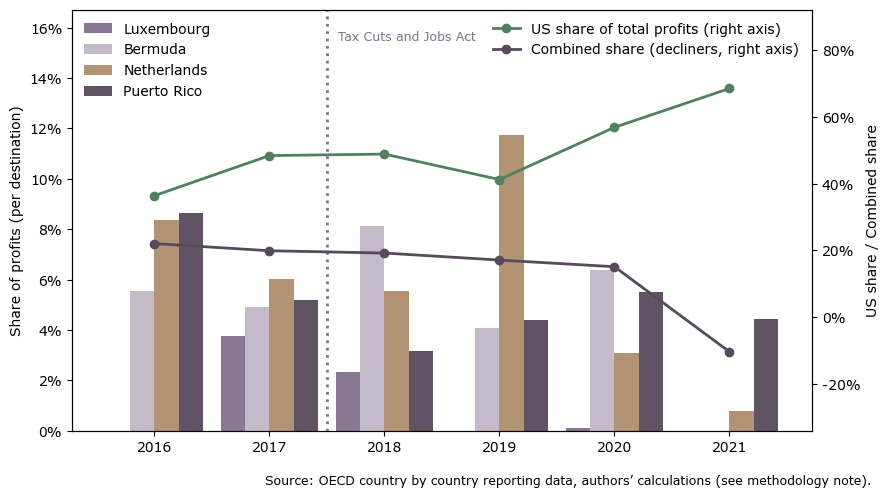

In [147]:
# Bars: clipped (no negatives in bars)
shares = compute_shares_by_year(
    cbcr_us,
    year_min=2016, year_max=2024,
    profit_col=None,
    positive_only=True,        # bars clean
    denominator="foreign"
)

# Line: unclipped (allow negatives in combined sum)
shares_unclipped = compute_shares_by_year(
    cbcr_us,
    year_min=2016, year_max=2024,
    profit_col=None,
    positive_only=False,       # include negatives
    denominator="foreign"
)

# Top 4 decliners (choose on unclipped truth)
decl4 = top_decliners_2016_2021(
    shares_unclipped, start_year=2016, end_year=2021,
    top_n=4, exclude_iso={"WXD"}  # US allowed
)

# US share of total profits (0–1 or 0–100)
us_share = compute_us_share_global(
    cbcr_us, year_min=2016, year_max=2024,
    profit_col=None, positive_only=True
)

fig, (ax1, ax2) = plot_grouped_bars_for_decliners(
    shares, decl4,
    shares_df_unclipped=shares_unclipped,   # <- combined line uses this (includes negatives)
    us_share_df=us_share,                   # <- US share line
    us_label="US share of total profits (right axis)",
    combined_positive_only=False,
    us_color=COLORS["earthgreen"],
    year_min=2016, year_max=2024,
    figsize=(9,5),
    annotate=False,
    title=""
)

fig.savefig(os.path.join(FIG_PATH, "figure_profit_shares_en.png"),
            dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(FIG_PATH2, "figure_profit_shares_en.png"),
            dpi=300, bbox_inches="tight")   
plt.show()


Support with Compustat data

In [148]:
years_wanted = [2016, 2021, 2024]

d = compustat_all.copy()

denom = (d["profits_in_us"].astype(float).fillna(0) + d["profits_foreign"].astype(float).fillna(0))
num = d["profits_in_us"].astype(float)

# Profit share in the US
d["us_profit_share"] = np.where(denom > 0, num / denom, np.nan)

# Median by year (restrict to the years of interest)
medians = (d[d["year"].isin(years_wanted)]
           .groupby("year", as_index=True)["us_profit_share"]
           .median()
           .sort_index())

means = (d[d["year"].isin(years_wanted)]
           .groupby("year", as_index=True)["us_profit_share"]
           .mean()
           .sort_index())

totalus = (d[d["year"].isin(years_wanted)]
           .groupby("year", as_index=True)["profits_in_us"]
           .sum()
           .sort_index())

totalforeign = (d[d["year"].isin(years_wanted)]
           .groupby("year", as_index=True)["profits_foreign"]
           .sum()
           .sort_index()) 

totalglobal = totalus + totalforeign
globalmean = (totalus / totalglobal).sort_index()

# Pretty print as percentages
for y, v in medians.items():
    pct = f"{100*v:.1f}%" if pd.notna(v) else "n/a"
    print(f"Median US profit share in {y}: {pct}")
for y, v in means.items():
    pct = f"{100*v:.1f}%" if pd.notna(v) else "n/a"
    print(f"Mean US profit share in {y}: {pct}")
for y, v in globalmean.items():
    pct = f"{100*v:.1f}%" if pd.notna(v) else "n/a"
    print(f"Global Mean US profit share in {y}: {pct}")



Median US profit share in 2016: 52.0%
Median US profit share in 2021: 61.6%
Median US profit share in 2024: 58.1%
Mean US profit share in 2016: 52.0%
Mean US profit share in 2021: 61.6%
Mean US profit share in 2024: 58.1%
Global Mean US profit share in 2016: 52.0%
Global Mean US profit share in 2021: 61.6%
Global Mean US profit share in 2024: 58.1%


#### US LUX Swap

In [149]:
# --- Prep: pull US and Luxembourg profits from your CbCR (US-parent) data ---
def prepare_us_lux_profits(
    cbcr_us: pd.DataFrame,
    *,
    profit_col: str | None = None,    # auto-pick corrected if present
    year_min: int = 2016,
    year_max: int = 2024
) -> pd.DataFrame:
    """
    Returns a tidy df with columns: year, profit_us, profit_lux (sum across groups/entities).
    Assumes cbcr_us already filtered to US-headquartered parents.
    """
    df = cbcr_us.copy()
    # Pick profit column (prefer corrected)
    if profit_col is None:
        profit_col = "profit_loss_before_income_tax_corrected" \
            if "profit_loss_before_income_tax_corrected" in df.columns \
            else "profit_loss_before_income_tax"
    df[profit_col] = pd.to_numeric(df[profit_col], errors="coerce")

    df = df[(df["year"] >= year_min) & (df["year"] <= year_max)].copy()

    # Sum profits for US rows (is_us_partner) and Luxembourg rows (iso_partner == 'LUX')
    df["is_us_partner"] = df["is_us_partner"].astype(bool)  # should already exist from your loader
    mask_us  = df["is_us_partner"] == True
    mask_lux = df["iso_partner"].astype(str).str.upper() == "LUX"

    g_us  = (df.loc[mask_us]
               .groupby("year", as_index=True)[profit_col].sum(min_count=1)
               .rename("profit_us"))
    g_lux = (df.loc[~mask_us & mask_lux]
               .groupby("year", as_index=True)[profit_col].sum(min_count=1)
               .rename("profit_lux"))

    out = pd.concat([g_us, g_lux], axis=1).reset_index()
    return out.sort_values("year")

# --- Plotter: indexed (recommended) or absolute levels ---
def plot_us_vs_lux_profits(
    d: pd.DataFrame,                   # from prepare_us_lux_profits
    *,
    mode: str = "indexed",             # "indexed" (recommended) or "absolute"
    base_years: tuple[int,...] = (2016,),  # used for indexing; can pass (2016,2017,2018)
    figsize=(9,5),
    annotate: bool = True,
    add_tcja: bool = True,
    tcja_year: float = 2017.5,
    tcja_color: str = None,
    tcja_linestyle: str = ":",
    tcja_linewidth: float = 2.0,
    unit_label: str = "USD"            # only used for absolute mode label text
):
    years = d["year"].to_numpy()
    x = np.arange(len(years))

    y_us  = d["profit_us"].to_numpy(dtype=float)
    y_lux = d["profit_lux"].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=figsize)

    if mode.lower() == "indexed":
        # Base = mean over base_years (robust to single-year noise/sign flips).
        def mk_index(y, yrs, base_years):
            mask = np.isin(yrs, list(base_years))
            base = np.nanmean(y[mask]) if mask.any() else np.nan
            return (y / base) * 100.0 if np.isfinite(base) and base != 0 else np.full_like(y, np.nan)

        idx_us  = mk_index(y_us, years, base_years)
        idx_lux = mk_index(y_lux, years, base_years)

        line_us,  = ax.plot(x, idx_us,  marker="o", linewidth=2, color=COLORS["dark_purple"],
                            label="Profits booked in the US (2016=100)")
        line_lux, = ax.plot(x, idx_lux, marker="o", linewidth=2, color=COLORS["blue"],
                            label="Profits booked in Luxembourg (2016=100)")

        # y-lims with modest headroom (handle negatives too)
        finite = np.concatenate([idx_us[np.isfinite(idx_us)], idx_lux[np.isfinite(idx_lux)]])
        ymin = np.nanmin(finite) if finite.size else 0.0
        ymax = np.nanmax(finite) if finite.size else 1.0
        pad = 0.08 * (ymax - ymin if ymax != ymin else 1.0)
        ax.set_ylim(ymin - pad, ymax + pad)

        ax.set_ylabel("Index (2016 = 100)")

        # optional labels (start/end)
        def label_end(xpos, yval, color):
            if np.isfinite(yval):
                ax.text(xpos, yval + 0.02*(ax.get_ylim()[1]-ax.get_ylim()[0]),
                        f"{yval:.0f}", color=color, ha="center", va="bottom", fontsize=8)
        if annotate and len(x):
            label_end(x[0],  idx_us[0],  COLORS["dark_purple"])
            label_end(x[-1], idx_us[-1], COLORS["dark_purple"])
            label_end(x[0],  idx_lux[0], COLORS["blue"])
            label_end(x[-1], idx_lux[-1], COLORS["blue"])

    else:  # "absolute"
        line_us,  = ax.plot(x, y_us,  marker="o", linewidth=2, color=COLORS["dark_purple"],
                            label="Profits booked in the US")
        line_lux, = ax.plot(x, y_lux, marker="o", linewidth=2, color=COLORS["blue"],
                            label="Profits booked in Luxembourg")

        finite = np.concatenate([y_us[np.isfinite(y_us)], y_lux[np.isfinite(y_lux)]])
        ymin = np.nanmin(finite) if finite.size else 0.0
        ymax = np.nanmax(finite) if finite.size else 1.0
        pad = 0.08 * (ymax - ymin if ymax != ymin else 1.0)
        ax.set_ylim(ymin - pad, ymax + pad)

        ax.set_ylabel(f"Profits ({unit_label})")
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))

        if annotate and len(x):
            ax.text(x[-1], y_us[-1],  f"{y_us[-1]:,.0f}",  color=COLORS["dark_purple"],
                    ha="left", va="center", fontsize=8)
            ax.text(x[-1], y_lux[-1], f"{y_lux[-1]:,.0f}", color=COLORS["blue"],
                    ha="left", va="center", fontsize=8)

    # X ticks, legend
    ax.set_xticks(x)
    ax.set_xticklabels(years.astype(int))
    ax.legend(loc="upper left", frameon=False)

    fig.tight_layout()
    return fig, ax


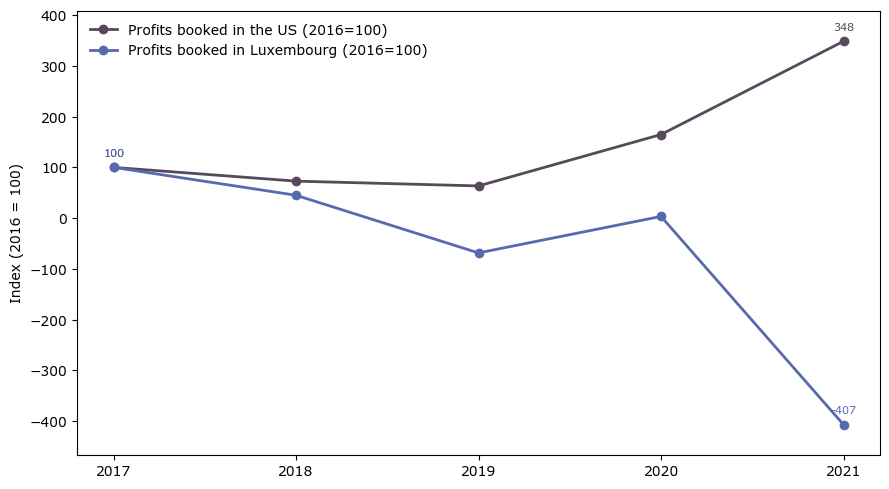

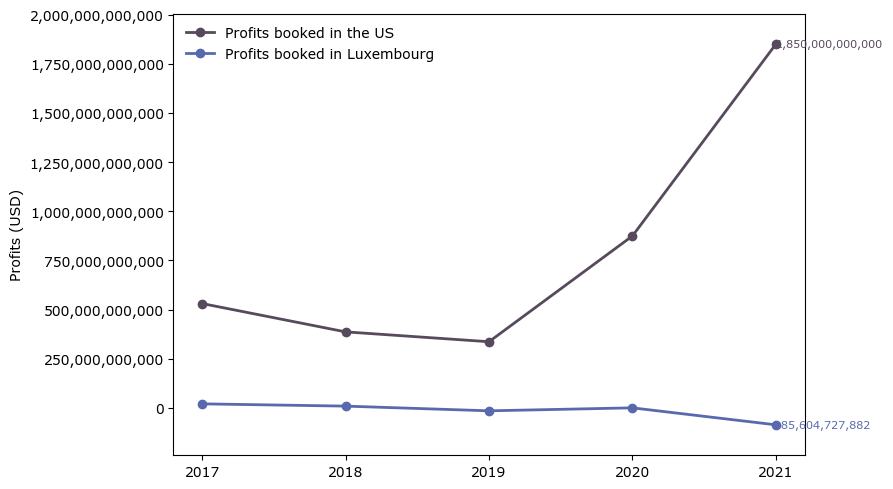

In [150]:
# 1) Build the US/Lux series from your US-parent CbCR
profits_us_lux = prepare_us_lux_profits(cbcr_us, year_min=2017, year_max=2024)

# 2) Recommended: indexed view (clear substitution signal)
fig_idx, ax_idx = plot_us_vs_lux_profits(
    profits_us_lux, mode="indexed", base_years=(2017,), figsize=(9,5)
)

# 3) Optional: absolute levels (appendix)
fig_abs, ax_abs = plot_us_vs_lux_profits(
    profits_us_lux, mode="absolute", figsize=(9,5), unit_label="USD"
)


#### Figure 6 to 8: Profits booked and taxes paid

In [151]:
# ---------------- Deflation helper (keep if not already defined) ----------------
def deflate_to_base(df, *, cpi_df, year_col="year", base_year=2024, extra_exclude=None):
    """
    Deflate all numeric columns (except [year_col] and any in extra_exclude) to base_year units.
    cpi_df must have columns: year, cpi (any base; rebased internally).
    """
    if extra_exclude is None:
        extra_exclude = []
    d = df.copy()
    c = cpi_df[[year_col, "cpi"]].dropna().copy()
    base_val = float(c.loc[c[year_col] == base_year, "cpi"].iloc[0])
    c["deflator"] = c["cpi"] / base_val  # nominal / base
    d = d.merge(c[[year_col, "deflator"]], on=year_col, how="left")

    exclude = set([year_col, "deflator"] + list(extra_exclude))
    num_cols = [col for col in d.select_dtypes(include="number").columns if col not in exclude]
    for col in num_cols:
        d[col] = d[col] / d["deflator"]
    d = d.drop(columns=["deflator"])
    return d

In [152]:
def plot_summary_bars(
    df: pd.DataFrame,
    *,
    cpi_df: pd.DataFrame,
    base_year: int = 2024,
    scope: str = "total",              # "total" | "domestic" | "foreign"
    year_min: int = 2016,
    year_max: int = 2024,
    figsize=(10,5),
    left_pad: float = 0.30             # extra space above bars
):
    d = df[(df["year"] >= year_min) & (df["year"] <= year_max)].copy()

    if scope == "total":
        profits_col, taxes_col = "profits_total_mnes", "tax_total_mnes"
        prof_label,  tax_label = "Total profits", "Total taxes paid"
    elif scope == "domestic":
        profits_col, taxes_col = "profits_in_us", "tax_us"
        prof_label,  tax_label = "Profits recorded in the US", "Taxes paid in the US"
    elif scope == "foreign":
        profits_col, taxes_col = "profits_foreign", "tax_foreign"
        prof_label,  tax_label = "Profits recorded abroad", "Taxes paid abroad"
    else:
        raise ValueError("scope must be 'total', 'domestic', or 'foreign'")

    d = d[["year", profits_col, taxes_col]].rename(
        columns={profits_col: "profits", taxes_col: "taxes"}
    )
    d[["profits","taxes"]] = d[["profits","taxes"]].fillna(0)

    # Deflate nominal mUSD to base_year mUSD (ETR not present here)
    d_defl = deflate_to_base(d, cpi_df=cpi_df, year_col="year",
                             base_year=base_year, extra_exclude=[]).sort_values("year")

    years = d_defl["year"].to_numpy()
    x = np.arange(len(years))
    bar_w = 0.40

    fig, ax1 = plt.subplots(figsize=figsize)

    profits_vals = d_defl["profits"].to_numpy()
    taxes_vals   = d_defl["taxes"].to_numpy()

    bars_profit = ax1.bar(
        x - bar_w/2, profits_vals, width=bar_w,
        label=f"{prof_label}", alpha=0.95,
        color=COLORS["light_purple"]
    )
    bars_tax = ax1.bar(
        x + bar_w/2, taxes_vals, width=bar_w,
        label=f"{tax_label}", alpha=0.95,
        color=COLORS["purple"]
    )

    ax1.set_xticks(x); ax1.set_xticklabels(years)
    ax1.set_ylabel(f"{base_year} mUSD")
    ax1.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))

    # Headroom (both axes start at 0; only left axis used here)
    def _max_finite(a):
        a = np.asarray(a); a = a[np.isfinite(a)]
        return float(a.max()) if a.size else 0.0

    peak = max(_max_finite(profits_vals), _max_finite(taxes_vals))
    left_top = (1 + left_pad)*peak if peak > 0 else 1.0
    ax1.set_ylim(0, left_top)
    
    add_tcja_marker(ax1, years=years, x_positions=x, tcja_year=2017.5,
            color=COLORS["purple"], linestyle=":", linewidth=2.0)

    # Data labels (mUSD)
    def _label_bars(bars):
        offset = 0.02 * left_top
        for b in bars:
            h = b.get_height()
            if not np.isfinite(h): 
                continue
            ax1.text(b.get_x() + b.get_width()/2, h + offset, f"{h:,.0f}",
                     ha="center", va="bottom", fontsize=8)

    _label_bars(bars_profit)
    _label_bars(bars_tax)

    ax1.legend(loc="upper left", frameon=False)
    
    fig.tight_layout()
    return fig, ax1

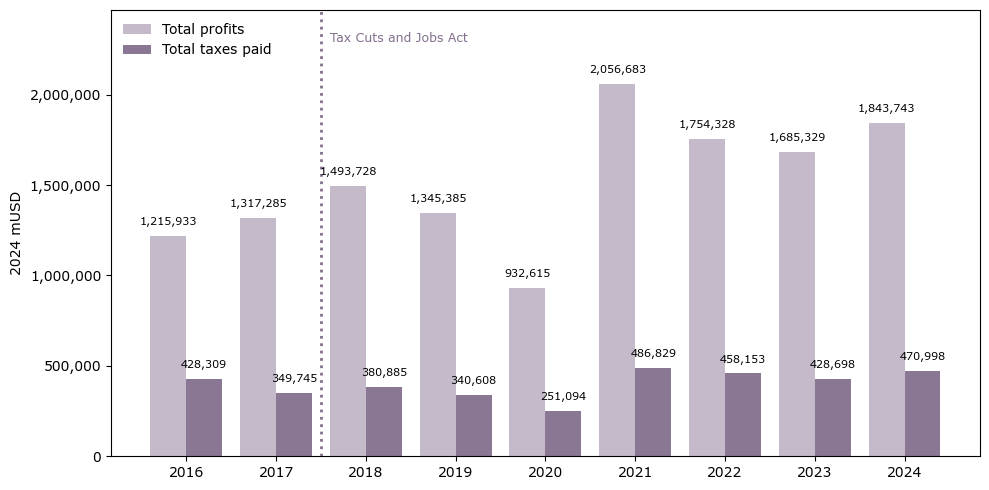

In [153]:
# Bars-only figure (no ETR), Total scope:
fig1, ax1 = plot_summary_bars(
    compustat_all, cpi_df=cpi_index, base_year=2024,
    scope="total", year_min=2016, year_max=2024, left_pad=0.20
    )
fig1.savefig(os.path.join(FIG_PATH,"figure_profits_taxes_total_en.png"), dpi=300, bbox_inches="tight")
fig1.savefig(os.path.join(FIG_PATH2,"figure_profits_taxes_total_en.png"), dpi=300, bbox_inches="tight")

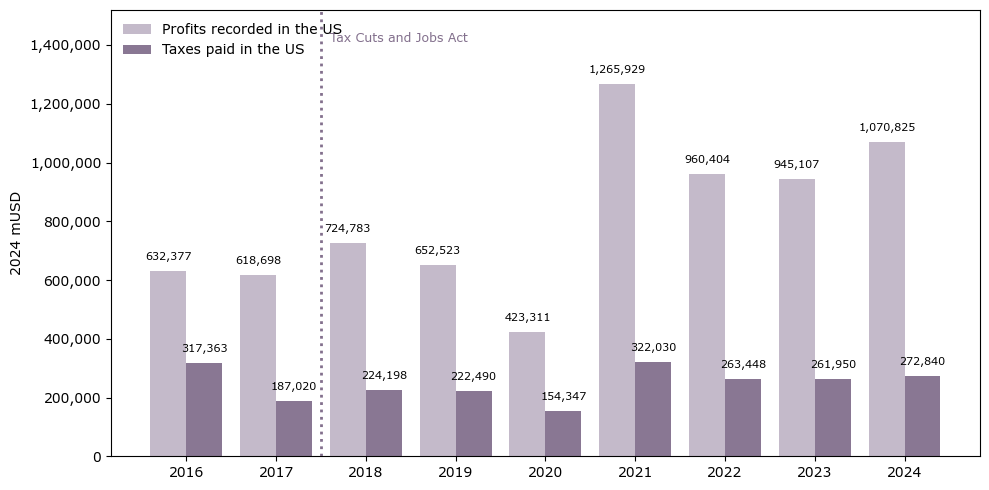

In [154]:
# Bars-only figure (no ETR), Total scope:
fig1, ax1 = plot_summary_bars(
    compustat_all, cpi_df=cpi_index, base_year=2024,
    scope="domestic", year_min=2016, year_max=2024, left_pad=0.20
)
fig1.savefig(os.path.join(FIG_PATH,"figure_profits_taxes_domestic_en.png"), dpi=300, bbox_inches="tight")
fig1.savefig(os.path.join(FIG_PATH2,"figure_profits_taxes_domestic_en.png"), dpi=300, bbox_inches="tight")


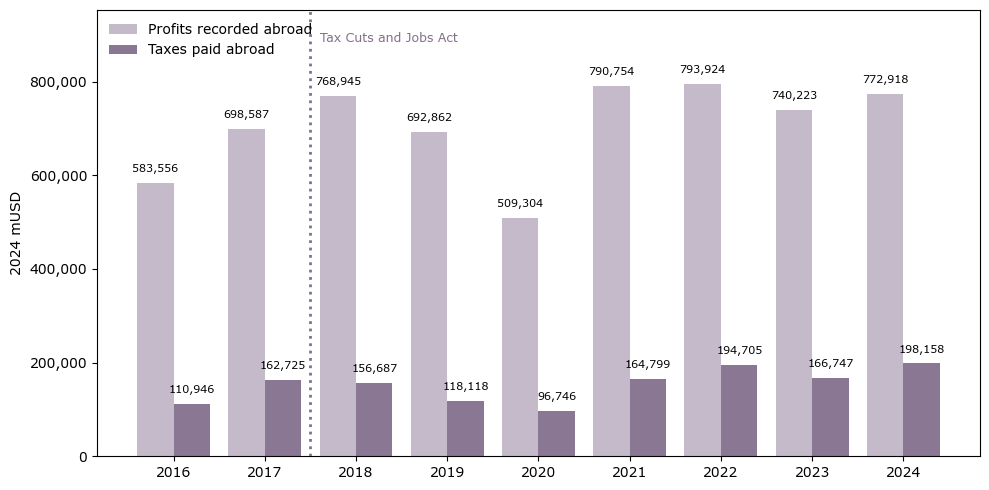

In [155]:
# Bars-only figure (no ETR), Total scope:
fig1, ax1 = plot_summary_bars(
    compustat_all, cpi_df=cpi_index, base_year=2024,
    scope="foreign", year_min=2016, year_max=2024, left_pad=0.20
)
fig1.savefig(os.path.join(FIG_PATH,"figure_profits_taxes_foreign_en.png"), dpi=300, bbox_inches="tight")
fig1.savefig(os.path.join(FIG_PATH2,"figure_profits_taxes_foreign_en.png"), dpi=300, bbox_inches="tight")

### Comparison US versus all Profits versus taxes

In [156]:
# ---------------- Deflation helper (keep if not already defined) ----------------
def deflate_to_base(df, *, cpi_df, year_col="year", base_year=2024, extra_exclude=None):
    """
    Deflate all numeric columns (except [year_col] and any in extra_exclude) to base_year units.
    cpi_df must have columns: year, cpi (any base; rebased internally).
    """
    if extra_exclude is None:
        extra_exclude = []
    d = df.copy()
    c = cpi_df[[year_col, "cpi"]].dropna().copy()
    base_val = float(c.loc[c[year_col] == base_year, "cpi"].iloc[0])
    c["deflator"] = c["cpi"] / base_val  # nominal / base
    d = d.merge(c[[year_col, "deflator"]], on=year_col, how="left")

    exclude = set([year_col, "deflator"] + list(extra_exclude))
    num_cols = [col for col in d.select_dtypes(include="number").columns if col not in exclude]
    for col in num_cols:
        d[col] = d[col] / d["deflator"]
    d = d.drop(columns=["deflator"])
    return d

In [157]:
def plot_two_year_profits_taxes(
    df: pd.DataFrame,
    *,
    cpi_df: pd.DataFrame,
    base_year: int = 2024,
    year_a: int = 2016,   
    year_b: int = 2024,
    figsize=(10,5),
    start_y_at_zero: bool = False,   # if True, include 0; if False, fit to data min/max
    ylabel_fontsize: int = 10,       # smaller y-axis label
    ytick_fontsize: int = 9,
    top_headroom: float = 0.08,
    totalprofits = "profits_total_mnes",
    totaltax     = "tax_total_mnes"

):
    """
    Two-panel figure:
      - Left: TOTAL (profits_total vs tax_total) for year_a and year_b
      - Right: DOMESTIC (profits_in_us vs tax_us) for year_a and year_b
    Left panel shows the y-axis label; right panel omits it.
    """
    needed = {"year", "profits_total", "tax_total", "profits_in_us", "tax_us"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns for two-year plot: {missing}")

    # --- Make year dtype consistent and numeric everywhere ---
    df = df.copy()
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

    cpi_df = cpi_df.copy()
    if "year" not in cpi_df.columns:
        raise ValueError("cpi_df must have a 'year' column.")
    cpi_df["year"] = pd.to_numeric(cpi_df["year"], errors="coerce").astype("Int64")

    # --- Filter for the two years and validate presence ---
    year_a = int(year_a); year_b = int(year_b); base_year = int(base_year)
    year_order = [year_a, year_b]

    d = df[df["year"].isin(year_order)].copy()
    if d.empty or set(year_order) - set(d["year"].dropna().astype(int)):
        raise ValueError(f"Data for years {year_a} and/or {year_b} not found in df.")

    # 1) Fill NaNs pre-deflation for metrics (but NOT the year)
    metric_cols = [totalprofits, totaltax, "profits_in_us", "tax_us"]
    d[metric_cols] = d[metric_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)

    # --- Sanity check CPI coverage for both years and base year ---
    missing_cpi_years = [y for y in (year_a, year_b, base_year) if y not in set(cpi_df["year"].dropna().astype(int))]
    if missing_cpi_years:
        raise ValueError(f"CPI missing for year(s): {missing_cpi_years}. Provide CPI for these years.")

    # 2) Deflate (assumes deflate_to_base merges on 'year' and preserves rows)
    d_defl = deflate_to_base(
        d[["year"] + metric_cols],
        cpi_df=cpi_df,
        year_col="year",
        base_year=base_year,
        extra_exclude=[]
    )

    # --- Enforce strict ordering and existence (raises if a year is absent) ---
    d_defl = d_defl.sort_values("year").set_index("year")
    try:
        d_defl = d_defl.loc[year_order]
    except KeyError as e:
        have = list(d_defl.index.tolist())
        raise ValueError(f"After deflation, expected years {year_order} but have {have}.") from e

    # 3) Coerce non-finite post-deflation (e.g., divide-by-zero issues)
    d_defl[metric_cols] = (
        d_defl[metric_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .astype(float)
    )


    dom_profits   = d_defl["profits_in_us"].to_numpy()
    dom_taxes     = d_defl["tax_us"].to_numpy()
    total_profits = d_defl[totalprofits].to_numpy()
    total_taxes   = d_defl[totaltax].to_numpy()

    


    fig, (ax_domestic, ax_total) = plt.subplots(1, 2, figsize=figsize, sharey=False)

    def _safe_ylim(profits_vals, taxes_vals, include_zero: bool):
        arr = np.concatenate([profits_vals.ravel(), taxes_vals.ravel()])
        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            return (-1.0, 1.0)
        data_min = float(arr.min()); data_max = float(arr.max())
        span = data_max - data_min
        pad = (0.06 * span) if span > 0 else 1.0
        if include_zero:
            y_min = min(0.0, data_min - pad); y_max = max(0.0, data_max + pad)
        else:
            y_min = data_min - pad; y_max = data_max + pad
        if y_min == y_max:
            bump = 1.0 if y_max == 0 else 0.06 * abs(y_max)
            y_min -= bump; y_max += bump
        rng = y_max - y_min
        y_max = y_max + top_headroom * rng
        return y_min, y_max

    def _plot_panel(ax, profits_vals, taxes_vals, title, show_ylabel: bool):
        x = np.array([0.0, 1.0])  # fixed centers for two years
        bar_w = 0.35

        bp = ax.bar(x - bar_w/2, profits_vals, width=bar_w,
                    label="Recorded profits", alpha=0.95, color=COLORS["light_purple"])
        bt = ax.bar(x + bar_w/2, taxes_vals, width=bar_w,
                    label="Taxes paid", alpha=0.95, color=COLORS["purple"])

        ax.set_xticks(x, labels=[str(y) for y in year_order])
        ax.set_xlim(-0.5, 1.5)
        ax.set_title(title)

        if show_ylabel:
            ax.set_ylabel(f"{base_year} mUSD", fontsize=ylabel_fontsize)
        else:
            ax.set_ylabel("")
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
        ax.tick_params(axis="y", labelsize=ytick_fontsize)

        y_min, y_max = _safe_ylim(profits_vals, taxes_vals, include_zero=start_y_at_zero)
        ax.set_ylim(y_min, y_max)

        # Data labels
        rng = ax.get_ylim()[1] - ax.get_ylim()[0]
        offset = 0.02 * rng
        for bars in (bp, bt):
            for b in bars:
                h = b.get_height()
                if np.isfinite(h) and (h != 0):
                    ax.text(b.get_x() + b.get_width()/2, h + offset, f"{h:,.0f}",
                            ha="center", va="bottom", fontsize=8)
        return bp, bt

    # Plot panels
    hp_dom,   ht_dom   = _plot_panel(ax_domestic, dom_profits, dom_taxes, "US activity of US multinationals", show_ylabel=True)
    hp_total, ht_total = _plot_panel(ax_total, total_profits, total_taxes, "Global activity of US multinationals", show_ylabel=False)
    
    # One combined legend
    fig.legend(handles=[hp_total[0], ht_total[0]], labels=["Profits", "Taxes paid"],
               loc="upper center", ncol=2, frameon=False)

    fig.tight_layout(rect=(0, 0.05, 1, .92))  # leave space at the bottom for the source
    fig.text(
        0.65, 0.015,
        "Source: Compustat North America, authors’ calculations.",
        ha="left", va="bottom", fontsize=9
    )
    return fig, ax_total, ax_domestic

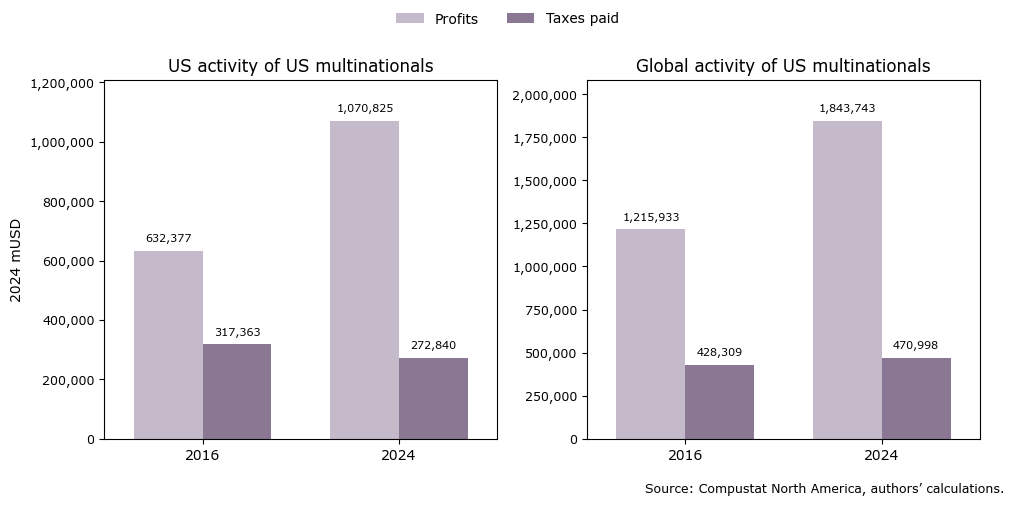

In [158]:
fig, ax_domestic, ax_total = plot_two_year_profits_taxes(totalprofits = "profits_total_mnes",totaltax = "tax_total_mnes",
    df=compustat_all, cpi_df=cpi_index, base_year=2024, year_a=2016, year_b=2024,
    start_y_at_zero=True  # set True if you prefer axes to include 0
)
fig.savefig(os.path.join(FIG_PATH, "figure_profits_taxes_2016_vs_2024_en.png"),
            dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(FIG_PATH2, "figure_profits_taxes_2016_vs_2024_en.png"),
            dpi=300, bbox_inches="tight")

In [159]:
# --- simple print block (no helpers) ---
a, b, byear = 2016, 2024, 2024            # set years/base to match your plot
totprof, tottax = "profits_total_mnes", "tax_total_mnes"

# subset & coerce
tmp = compustat_all[compustat_all["year"].isin([a, b])][["year", totprof, tottax, "profits_in_us", "tax_us"]].copy()
tmp_defl = deflate_to_base(tmp, cpi_df=cpi_index, year_col="year", base_year=byear, extra_exclude=[])
tmp_defl = tmp_defl.sort_values("year").set_index("year").loc[[a, b]]

# pull values
tp_a = float(tmp_defl.loc[a, totprof]); tp_b = float(tmp_defl.loc[b, totprof])
up_a = float(tmp_defl.loc[a, "profits_in_us"]); up_b = float(tmp_defl.loc[b, "profits_in_us"])
tt_a = float(tmp_defl.loc[a, tottax]);  tt_b = float(tmp_defl.loc[b, tottax])
ut_a = float(tmp_defl.loc[a, "tax_us"]); ut_b = float(tmp_defl.loc[b, "tax_us"])

# deltas (abs + %)
tp_d = tp_b - tp_a; tp_pct = ((tp_b / tp_a) - 1.0) * 100 if tp_a != 0 else float("nan")
up_d = up_b - up_a; up_pct = ((up_b / up_a) - 1.0) * 100 if up_a != 0 else float("nan")
tt_d = tt_b - tt_a; tt_pct = ((tt_b / tt_a) - 1.0) * 100 if tt_a != 0 else float("nan")
ut_d = ut_b - ut_a; ut_pct = ((ut_b / ut_a) - 1.0) * 100 if ut_a != 0 else float("nan")

# ETRs
etr_all_a = (tt_a / tp_a) if tp_a != 0 else float("nan")
etr_all_b = (tt_b / tp_b) if tp_b != 0 else float("nan")
etr_us_a  = (ut_a / up_a) if up_a != 0 else float("nan")
etr_us_b  = (ut_b / up_b) if up_b != 0 else float("nan")

# print
print(f"[{byear} mUSD] Increase in TOTAL profits:  {tp_d:,.0f} ({tp_pct:+.1f}%)" if np.isfinite(tp_pct) else f"[{byear} mUSD] Increase in TOTAL profits:  {tp_d:,.0f} (n/a)")
print(f"[{byear} mUSD] Increase in US profits:     {up_d:,.0f} ({up_pct:+.1f}%)" if np.isfinite(up_pct) else f"[{byear} mUSD] Increase in US profits:     {up_d:,.0f} (n/a)")
print(f"[{byear} mUSD] Increase in TOTAL taxes:    {tt_d:,.0f} ({tt_pct:+.1f}%)" if np.isfinite(tt_pct) else f"[{byear} mUSD] Increase in TOTAL taxes:    {tt_d:,.0f} (n/a)")
print(f"[{byear} mUSD] Increase in US taxes:       {ut_d:,.0f} ({ut_pct:+.1f}%)" if np.isfinite(ut_pct) else f"[{byear} mUSD] Increase in US taxes:       {ut_d:,.0f} (n/a)")
print(f"ETR (All): {a}: {etr_all_a*100:.1f}%  →  {b}: {etr_all_b*100:.2f}%  (Δ {(etr_all_b-etr_all_a)*100:+.1f} pp)" if np.isfinite(etr_all_a) and np.isfinite(etr_all_b) else f"ETR (All): {a}: n/a → {b}: n/a")
print(f"ETR (US):  {a}: {etr_us_a*100:.1f}%   →  {b}: {etr_us_b*100:.2f}%   (Δ {(etr_us_b-etr_us_a)*100:+.1f} pp)"  if np.isfinite(etr_us_a) and np.isfinite(etr_us_b) else f"ETR (US):  {a}: n/a → {b}: n/a")


[2024 mUSD] Increase in TOTAL profits:  627,810 (+51.6%)
[2024 mUSD] Increase in US profits:     438,448 (+69.3%)
[2024 mUSD] Increase in TOTAL taxes:    42,689 (+10.0%)
[2024 mUSD] Increase in US taxes:       -44,523 (-14.0%)
ETR (All): 2016: 35.2%  →  2024: 25.55%  (Δ -9.7 pp)
ETR (US):  2016: 50.2%   →  2024: 25.48%   (Δ -24.7 pp)


In [160]:
counterfactualtaxestotal = tp_b * etr_all_a
missingpart = counterfactualtaxestotal - tt_b
print(f"Had US multinationals' in 2024 paid the same ETR as in 2016, the world would have had {missingpart:,.0f} mUSD more in tax revenue. This is the difference between actual 2024 taxes ({tt_b:,.0f} mUSD) and counterfactual taxes ({counterfactualtaxestotal:,.0f} mUSD) paid on 2024 profits of {tp_b:,.0f} with the 2016 ETR of {etr_all_a}.")

Had US multinationals' in 2024 paid the same ETR as in 2016, the world would have had 178,455 mUSD more in tax revenue. This is the difference between actual 2024 taxes (470,998 mUSD) and counterfactual taxes (649,452 mUSD) paid on 2024 profits of 1,843,743 with the 2016 ETR of 0.35224678787513103.


In [161]:
profits_wo_tcja = up_a * (1 + tp_pct / 100)
profit_share_old = up_a/tp_a
profits_wo_tcja_check = tp_b * profit_share_old
taxes_wo_tcja = profits_wo_tcja * .35
tax_loss_from_tcja = taxes_wo_tcja - ut_b
pct_loss_from_tcja = (tax_loss_from_tcja / ut_b) * 100 if taxes_wo_tcja !=0 else float("nan")
print(f"The US lost {tax_loss_from_tcja} mUSD in tax revenue from TCJA. Assuming that profits would have grown at the same rate as total profits ({tp_pct}),US profits in {b} would have been {profits_wo_tcja:,.0f} mUSD without TCJA,leading to {taxes_wo_tcja:,.0f} mUSD in taxes paid with the old statutory tax rate of 35% (this is {pct_loss_from_tcja} actual tax payments of {ut_b:,.0f} mUSD). ")

The US lost 62770.18332376605 mUSD in tax revenue from TCJA. Assuming that profits would have grown at the same rate as total profits (51.63192373999057),US profits in 2024 would have been 958,885 mUSD without TCJA,leading to 335,610 mUSD in taxes paid with the old statutory tax rate of 35% (this is 23.00625558108014 actual tax payments of 272,840 mUSD). 


In [162]:
print(up_a)
print(ut_a)
print(up_b)
print(ut_b)

632376.8545630615
317362.92330770334
1070824.741418203
272839.6331273783


#### Total profits and taxes based on CbCR data

In [163]:

# ---------------- Deflation helper (keep if not already defined) ----------------
def deflate_to_base(df, *, cpi_df, year_col="year", base_year=2024, extra_exclude=None):
    """
    Deflate all numeric columns (except [year_col] and any in extra_exclude) to base_year units.
    cpi_df must have columns: year, cpi (any base; rebased internally).
    """
    if extra_exclude is None:
        extra_exclude = []
    d = df.copy()
    c = cpi_df[[year_col, "cpi"]].dropna().copy()
    base_val = float(c.loc[c[year_col] == base_year, "cpi"].iloc[0])
    c["deflator"] = c["cpi"] / base_val  # nominal / base
    d = d.merge(c[[year_col, "deflator"]], on=year_col, how="left")

    exclude = set([year_col, "deflator"] + list(extra_exclude))
    num_cols = [col for col in d.select_dtypes(include="number").columns if col not in exclude]
    for col in num_cols:
        d[col] = d[col] / d["deflator"]
    d = d.drop(columns=["deflator"])
    return d

# ---------------- Your plotters (paste your existing versions if you’ve customized them) --------
def plot_summary_bars(
    df: pd.DataFrame,
    *,
    cpi_df: pd.DataFrame,
    base_year: int = 2024,
    scope: str = "total",              # "total" | "domestic" | "foreign"
    year_min: int = 2016,
    year_max: int = 2024,
    figsize=(10,5),
    left_pad: float = 0.30
):
    d = df[(df["year"] >= year_min) & (df["year"] <= year_max)].copy()

    if scope == "total":
        profits_col, taxes_col = "profits_total", "tax_total"
        prof_label,  tax_label = "Total profits", "Total taxes paid"
    elif scope == "domestic":
        profits_col, taxes_col = "profits_in_us", "tax_us"
        prof_label,  tax_label = "Profits recorded in the US", "Taxes paid in the US"
    elif scope == "foreign":
        profits_col, taxes_col = "profits_foreign", "tax_foreign"
        prof_label,  tax_label = "Profits recorded abroad", "Taxes paid abroad"
    else:
        raise ValueError("scope must be 'total', 'domestic', or 'foreign'")

    d = d[["year", profits_col, taxes_col]].rename(columns={profits_col: "profits", taxes_col: "taxes"})
    d[["profits","taxes"]] = d[["profits","taxes"]].fillna(0)

    d_defl = deflate_to_base(d, cpi_df=cpi_df, year_col="year",
                             base_year=base_year, extra_exclude=[]).sort_values("year")

    years = d_defl["year"].to_numpy()
    x = np.arange(len(years))
    bar_w = 0.40

    fig, ax1 = plt.subplots(figsize=figsize)

    profits_vals = d_defl["profits"].to_numpy()
    taxes_vals   = d_defl["taxes"].to_numpy()

    bars_profit = ax1.bar(
        x - bar_w/2, profits_vals, width=bar_w,
        label=f"{prof_label}", alpha=0.95,
        color=COLORS["light_purple"]
    )
    bars_tax = ax1.bar(
        x + bar_w/2, taxes_vals, width=bar_w,
        label=f"{tax_label}", alpha=0.95,
        color=COLORS["purple"]
    )

    ax1.set_xticks(x); ax1.set_xticklabels(years.astype(int))
    ax1.set_ylabel(f"{base_year} mUSD")
    ax1.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))

    # Robust y-limits (handles negatives if present)
    min_val = min(np.nanmin(profits_vals), np.nanmin(taxes_vals))
    max_val = max(np.nanmax(profits_vals), np.nanmax(taxes_vals))
    pad = left_pad if max_val > 0 else 0.10
    y_min = min(0.0, float(min_val) * 1.10)
    y_max = (1 + pad) * float(max_val) if max_val > 0 else 1.0
    ax1.set_ylim(y_min, y_max)

    # TCJA marker (uses your existing add_tcja_marker)
    add_tcja_marker(ax1, years=years.astype(float), x_positions=x, tcja_year=2017.5,
                    color=COLORS["purple"], linestyle=":", linewidth=2.0)

    # Data labels
    def _label_bars(bars):
        offset = 0.02 * (ax1.get_ylim()[1] - ax1.get_ylim()[0])
        for b in bars:
            h = b.get_height()
            if not np.isfinite(h): 
                continue
            ax1.text(b.get_x() + b.get_width()/2, h + offset, f"{h:,.0f}",
                     ha="center", va="bottom", fontsize=8)
    _label_bars(bars_profit)
    _label_bars(bars_tax)

    ax1.legend(loc="upper left", frameon=False)
    fig.tight_layout()
    return fig, ax1

def aggregate_us_nonus_shares(
    df: pd.DataFrame,
    metrics: list[str],
    *,
    year_min: int = 2016,
    year_max: int = 2024
) -> pd.DataFrame:
    needed = ["year", "is_us_partner"] + metrics
    for c in needed:
        if c not in df.columns:
            raise ValueError(f"Missing column: {c}")

    d = df.loc[(df["year"] >= year_min) & (df["year"] <= year_max), needed].copy()
    g = d.groupby(["year","is_us_partner"], as_index=False).agg({m: "sum" for m in metrics})

    wide_parts = []
    years = sorted(d["year"].dropna().unique())
    for m in metrics:
        w = g.pivot(index="year", columns="is_us_partner", values=m).reindex(years)
        if True  not in w.columns: w[True]  = 0.0
        if False not in w.columns: w[False] = 0.0
        w = w.rename(columns={True: f"{m}_us", False: f"{m}_nonus"})
        wide_parts.append(w)

    out = pd.concat(wide_parts, axis=1).reset_index()

    for m in metrics:
        out[f"{m}_total"] = out[f"{m}_us"] + out[f"{m}_nonus"]
        with np.errstate(divide="ignore", invalid="ignore"):
            out[f"{m}_us_share"] = np.where(out[f"{m}_total"] > 0,
                                            out[f"{m}_us"] / out[f"{m}_total"], np.nan)
    return out

def plot_us_share_lines(
    agg: pd.DataFrame,
    series: list[tuple[str, str, str]],  # (share_col, label, color_key)
    *,
    title: str = "",
    ylabel: str = "US share (%)",
    figsize=(9,5),
    y0: float = 0,
    y1: float = 100
):
    years = np.sort(agg["year"].to_numpy())
    x = np.arange(len(years), dtype=float)

    fig, ax = plt.subplots(figsize=figsize)

    for share_col, label, ckey in series:
        y = (agg.set_index("year").reindex(years)[share_col] * 100.0).to_numpy(dtype=float)
        ax.plot(x, y, marker="o", linewidth=2, label=label, color=COLORS.get(ckey, "black"))

    ax.set_xticks(x)
    ax.set_xticklabels(years.astype(int))
    ax.set_ylim(y0, y1)
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))

    add_tcja_marker(
        ax,
        years=years.astype(float),
        x_positions=x,
        tcja_year=2017.5,
        y_pos="bottom", pad_frac=0.06,
        color=COLORS["purple"],
        linestyle=":",
        linewidth=2.0,
        show_label=True
    )

    if title:
        ax.set_title(title)

    ax.legend(loc="upper left", frameon=False)
    fig.tight_layout(rect=(0, 0.05, 1, 1))  # leave space at the bottom for the source
    fig.text(
        0.3, 0.015,
        "Source: OECD country by country reporting data, authors’ calculations (see methodology note).",
        ha="left", va="bottom", fontsize=9
    )
    return fig, ax

# ---------------- Transformer from cbcr_us to plotting metrics ----------------
COL_PROFIT = "profit_loss_before_income_tax_corrected"
COL_TAX    = "income_tax_paid_on_cash_basis"   # or "income_tax_accrued_current_year"

def build_plot_metrics_from_cbcr_us(cbcr_us: pd.DataFrame) -> pd.DataFrame:
    """
    Input: cbcr_us with at least: year, is_us_partner, COL_PROFIT, COL_TAX
    Output per-year totals with columns expected by plotters:
        year, profits_total, tax_total, profits_in_us, tax_us, profits_foreign, tax_foreign
    """
    needed = {"year", "is_us_partner", COL_PROFIT, COL_TAX}
    missing = needed - set(cbcr_us.columns)
    if missing:
        raise ValueError(f"Missing columns in cbcr_us: {missing}")

    d = cbcr_us[["year", "is_us_partner", COL_PROFIT, COL_TAX]].copy()
    d.rename(columns={COL_PROFIT: "profits", COL_TAX: "taxes"}, inplace=True)

    g = d.groupby(["year", "is_us_partner"], as_index=False)[["profits", "taxes"]].sum()
    w = g.pivot(index="year", columns="is_us_partner", values=["profits", "taxes"]).fillna(0.0)

    for lvl0 in ["profits", "taxes"]:
        for key in [True, False]:
            if key not in w.columns.get_level_values(1):
                w[(lvl0, key)] = 0.0

    w = w.sort_index().sort_index(axis=1)
    w.columns = [f"{a}_{'us' if b else 'foreign'}" for a, b in w.columns]

    out = w.reset_index()
    out["profits_total"] = out["profits_us"] + out["profits_foreign"]
    out["tax_total"]     = out["taxes_us"]   + out["taxes_foreign"]

    out.rename(columns={"taxes_us": "tax_us", "profits_us": "profits_in_us",
                        "taxes_foreign": "tax_foreign"}, inplace=True)

    keep = ["year", "profits_total", "tax_total", "profits_in_us", "tax_us",
            "profits_foreign", "tax_foreign"]
    return out[keep].sort_values("year")

# ---------------- Driver to create & save charts ----------------
def generate_cbcr_charts(
    df: pd.DataFrame,
    cpi_df: pd.DataFrame,
    *,
    outdir: Path,
    base_year: int = 2021,
    year_min: int = 2016,
    year_max: int = 2021,
    show = True,
):
    outdir.mkdir(parents=True, exist_ok=True)

    # 1) Summary bars for total/domestic/foreign
    for scope in ["total", "domestic", "foreign"]:
        fig, ax = plot_summary_bars(
            df,
            cpi_df=cpi_df,
            base_year=base_year,
            scope=scope,
            year_min=year_min,
            year_max=year_max,
            figsize=(10,5),
            left_pad=0.30
        )
        fig.savefig(outdir / f"summary_bars_{scope}_{year_min}-{year_max}_base{base_year}.png",
                    dpi=200, bbox_inches="tight")
        if show:
            plt.show()
        else:
            plt.close(fig)

    # 2) US vs non-US shares on original cbcr_us (expects is_us_partner)
    #    If you prefer to plot shares on deflated totals, compute metrics first and adapt.
    # (Here we assume you have the original cbcr_us in scope when you call this.)
    # This function just creates bar plots; the share lines are plotted separately below.

# ---------------- Example usage ----------------
# Provide your own cbcr_us and cpi_df DataFrames before running the block below.


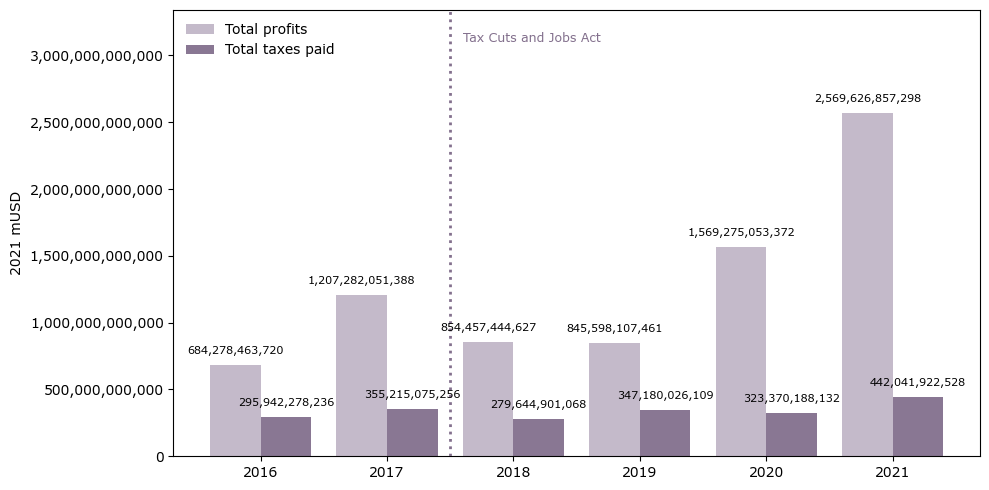

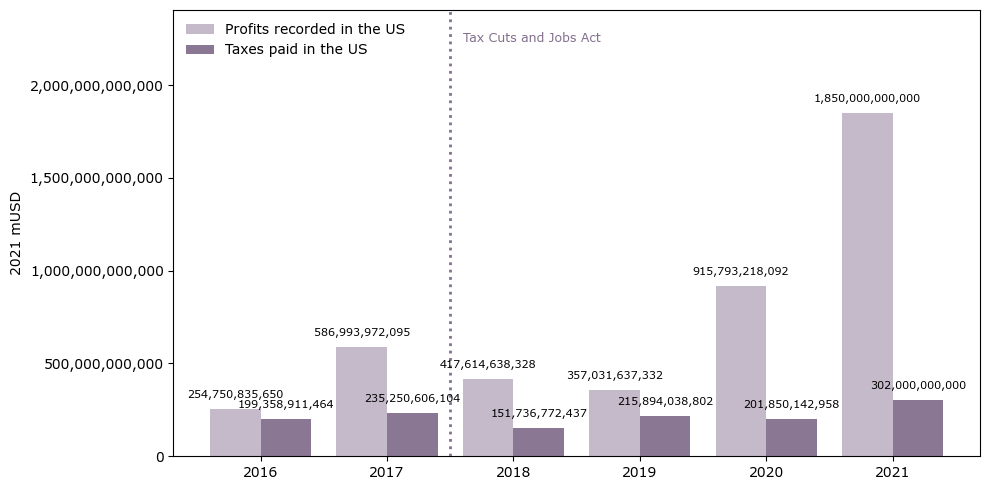

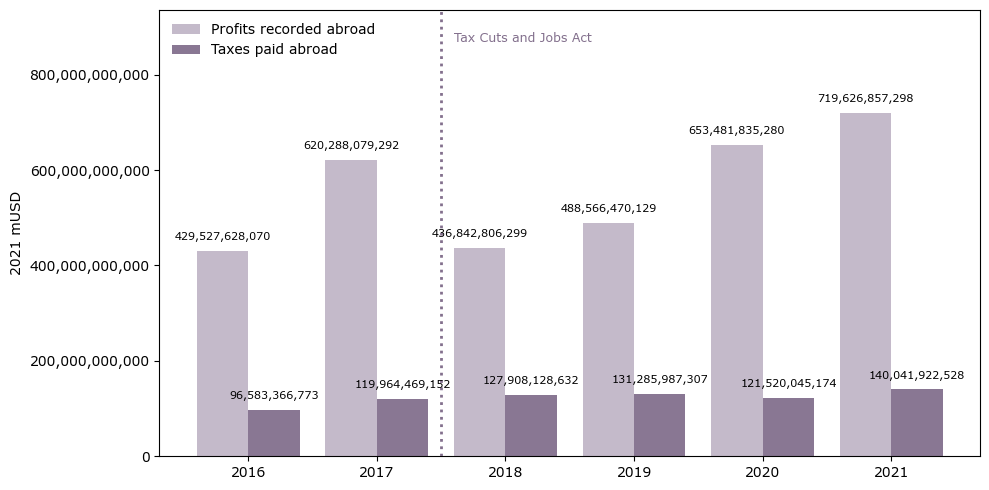

In [164]:
cbcr_plot_df = build_plot_metrics_from_cbcr_us(cbcr_us)
charts_dir = Path(FIG_PATH) / "figure_profits_taxes_domestic_cbcr"
charts_dir.mkdir(parents=True, exist_ok=True)  # optional: create upfront

generate_cbcr_charts(
    df=cbcr_plot_df,
    cpi_df=cpi_index,
    outdir=charts_dir,
    base_year=2021,
    year_min=2016,
    year_max=2021,
    show = True,
)

# Compute US vs non-US shares directly from original cbcr_us
shares = aggregate_us_nonus_shares(
    cbcr_us.rename(columns={
        COL_PROFIT: "profits_total",
        COL_TAX:    "tax_total"
    }),
    metrics=["profits_total", "tax_total"],
    year_min=2016, year_max=2024
)
fig, ax = plot_us_share_lines(
    shares,
    series=[
        ("profits_total_us_share", "US share of profits", "blue"),
        ("tax_total_us_share",     "US share of taxes",   "orange"),
    ],
    title="US Share of Profits and Taxes (US-HQ MNEs)",
    ylabel="US share (%)",
    figsize=(9,5),
    y0=0, y1=100
)
fig.savefig(Path(FIG_PATH) / "figure_profits_taxes_domestic_cbcr.png", dpi=200, bbox_inches="tight")
fig.savefig(Path(FIG_PATH2) / "figure_profits_taxes_domestic_cbcr.png", dpi=200, bbox_inches="tight")
plt.close(fig)


#### Figure XX: Share of employment and payroll

In [165]:
# ---------- Aggregate US vs non-US & compute shares ----------
def aggregate_us_nonus_shares(
    df: pd.DataFrame,
    metrics: list[str],
    *,
    year_min: int = 2016,
    year_max: int = 2024
) -> pd.DataFrame:
    """
    For each metric in `metrics`, compute per-year totals for US and non-US and create:
      {metric}_us, {metric}_nonus, {metric}_total, {metric}_us_share
    Returns a wide per-year dataframe.
    """
    needed = ["year", "is_us_partner"] + metrics
    for c in needed:
        if c not in df.columns:
            raise ValueError(f"Missing column: {c}")

    d = df.loc[(df["year"] >= year_min) & (df["year"] <= year_max), needed].copy()

    # Sum by (year, is_us_partner)
    g = d.groupby(["year","is_us_partner"], as_index=False).agg({m: "sum" for m in metrics})

    # Pivot to wide US / non-US per metric
    wide_parts = []
    years = sorted(d["year"].dropna().unique())
    for m in metrics:
        w = g.pivot(index="year", columns="is_us_partner", values=m).reindex(years)
        if True  not in w.columns: w[True]  = 0.0
        if False not in w.columns: w[False] = 0.0
        w = w.rename(columns={True: f"{m}_us", False: f"{m}_nonus"})
        wide_parts.append(w)

    out = pd.concat(wide_parts, axis=1).reset_index()

    # Totals & US shares
    for m in metrics:
        out[f"{m}_total"] = out[f"{m}_us"] + out[f"{m}_nonus"]
        with np.errstate(divide="ignore", invalid="ignore"):
            out[f"{m}_us_share"] = np.where(out[f"{m}_total"] > 0,
                                            out[f"{m}_us"] / out[f"{m}_total"], np.nan)
    return out


# ---------- Plotters ----------
from matplotlib.ticker import FuncFormatter
import numpy as np

def plot_us_share_lines(
    agg: pd.DataFrame,
    series: list[tuple[str, str, str]],  # (share_col, label, color_key)
    *,
    title: str = "",
    ylabel: str = "US share (%)",
    figsize=(9,5),
    y0: float = 0,
    y1: float = 100
):
    """
    Plot multiple US-share lines from `agg`.
    `series` list: each item is (share_column_name, legend label, COLORS key).
    """
    years = np.sort(agg["year"].to_numpy())
    x = np.arange(len(years), dtype=float)

    fig, ax = plt.subplots(figsize=figsize)

    # Plot each share series
    for share_col, label, ckey in series:
        y = (agg.set_index("year").reindex(years)[share_col] * 100.0).to_numpy(dtype=float)
        ax.plot(x, y, marker="o", linewidth=2, label=label, color=COLORS.get(ckey, "black"))

    ax.set_xticks(x)
    ax.set_xticklabels(years.astype(int))
    ax.set_ylim(y0, y1)
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))

    # --- TCJA marker (after y-lims so label isn't clipped) ---
    add_tcja_marker(
        ax,
        years=years.astype(float),
        x_positions=x,
        tcja_year=2017.5,
        y_pos="bottom", pad_frac=0.06,
        color=COLORS["purple"],
        linestyle=":",
        linewidth=2.0,
        show_label=True,
        line_top_frac=0.86   # << stops the dashed line under the legend area
    )

    if title:
        ax.set_title(title)

    ax.legend(loc="upper left", frameon=False)
    fig.tight_layout(rect=(0, 0.05, 1, 1))  # leave space at the bottom for the source
    fig.text(
        0.3, 0.015,
        "Source: OECD country by country reporting data, authors’ calculations (see methodology note).",
        ha="left", va="bottom", fontsize=9
    )
    return fig, ax


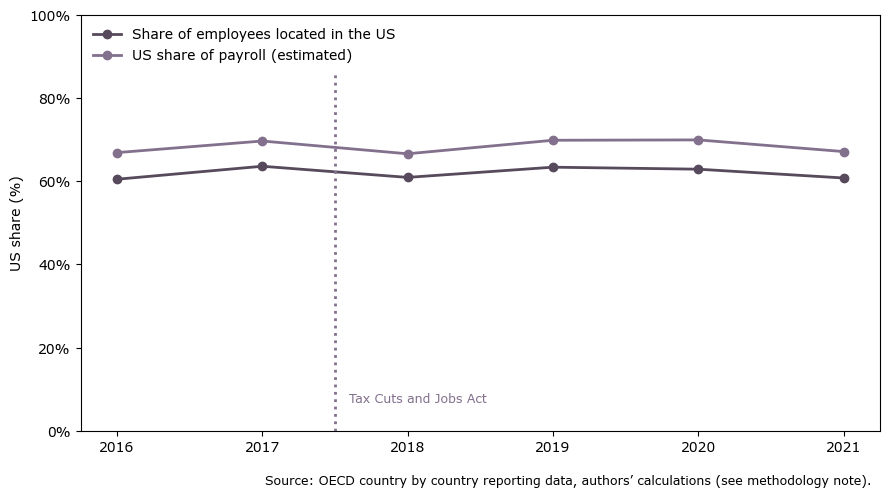

In [166]:
metrics = ["n_employees", "payroll"]
agg = aggregate_us_nonus_shares(cbcr_us, metrics, year_min=2016, year_max=2024)

fig, ax = plot_us_share_lines(
    agg,
    series=[
        ("n_employees_us_share", "Share of employees located in the US", "dark_purple"),
        ("payroll_us_share",     "US share of payroll (estimated)",    "purple"),
    ],
    title="",
    figsize=(9,5)
)

fig.savefig(os.path.join(FIG_PATH, "figure_us_share_employment_en.png"),
            dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(FIG_PATH2, "figure_us_share_employment_en.png"),
            dpi=300, bbox_inches="tight")
